# BE vs SC Grid-Search Cross-Validation (Manuscript Method)

**Purpose**: Fit BE and SC models to real mouse data using the manuscript's grid-search
procedure, then compare via 2-fold CV × 64 seeds with ANOVA.

**Method** (from manuscript):
1. Grid search over 4 parameters per model (Tables 2 & 3)
2. For each parameter set: 1000 simulated expert burn-in trials, then expose to real stimuli
3. Fit to conditional psychometric matrices (not update matrices directly)
4. 2-fold CV: split by blocks, fit on train, evaluate MSE on test
5. Repeat 64 times with different seeds → 64 avg test errors per model per animal
6. ANOVA to compare BE vs SC per animal

**Data bridge**: Loads via `behav_utils`, converts to flat DataFrame for old code.

---

**Potential issues to watch for**:
- Grid search is computationally expensive (10×4×20×10 = 8000 param combos per fold per seed)
- With parallelisation via joblib it's manageable, but 64 seeds × 2 folds × 2 models = 256 grid searches per animal
- NaN psychometric fits on sparse folds can inflate errors
- Mouse data may have fewer blocks than humans/rats, making 2-fold splits uneven
- `is_not_start_of_block` must be recomputed after pooling sessions

## 0. Setup & Imports

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats as sp_stats
from pathlib import Path
from tqdm import tqdm
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [2]:
# ── Import old code ───────────────────────────────────────────────────────────
from Old.Fitter import (
    k_fold_CV,
    post_correct_update_matrix,
    post_correct_conditional_stimuli,
    post_correct_total_stimuli,
    fit_Psych_curve,
    matrix_error,
    psychometric_model,
)
from Old.BE import BE_model
from Old.SC import SC_model

# ── Import behav_utils ─────────────────────────────────────────────────────────
from behav_utils.data.loading import load_experiment
from behav_utils.data.structures import AnimalData, SessionData

## 1. Configuration

In [43]:
# ── Data config ────────────────────────────────────────────────────────────────
CONFIG_PATH = '/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/config.yaml'

STAGE = 'Full_Task_Cont'
DISTRIBUTION = 'Uniform'
EXPERT_MIN_ACCURACY = 0.70
EXPERT_LAST_FRACTION = 0.50
MIN_EXPERT_SESSIONS = 5
TARGET_ANIMAL = None        # None = all qualifying animals; or e.g. 'SS05'

# ── CV config (manuscript protocol) ────────────────────────────────────────────
N_FOLDS = 2                 # 2-fold CV
N_SEEDS = 64                # 64 repetitions with different seeds
FIT_WITH = 'update'    # fit to conditional psychometric matrices
MODE_PRE = 'simulated'      # 1000-trial simulated burn-in

# ── Grid search parameters (Tables 2 & 3 from manuscript) ──────────────────────
SIGMA_NOISE_VALUES = np.linspace(0.05, 0.30, 10)
A_REPULSION_VALUES = np.linspace(0.0, 0.5, 4)

# BE-specific: y_axis = eta_learning, x_axis = eta_relax
BE_ETA_LEARNING_VALUES = np.linspace(0.1, 0.9, 20)   # y_axis
BE_ETA_RELAX_VALUES    = np.linspace(0.05, 0.4, 10)   # x_axis

# SC-specific: y_axis = gamma, x_axis = sigma_update
SC_GAMMA_VALUES        = np.linspace(0.1, 1.0, 20)    # y_axis
SC_SIGMA_UPDATE_VALUES = np.linspace(0.1, 1.0, 10)    # x_axis

# # ── COARSE grid (quick validation) ────────────────────────────────────────────
# SIGMA_NOISE_VALUES = np.linspace(0.05, 0.30, 4)    # 4 instead of 10
# A_REPULSION_VALUES = np.array([0.0, 0.25, 0.5])    # 3 instead of 4

# BE_ETA_LEARNING_VALUES = np.linspace(0.1, 0.9, 8)  # 8 instead of 20
# BE_ETA_RELAX_VALUES    = np.linspace(0.05, 0.4, 4)  # 4 instead of 10

# SC_GAMMA_VALUES        = np.linspace(0.1, 1.0, 8)   # 8 instead of 20
# SC_SIGMA_UPDATE_VALUES = np.linspace(0.1, 1.0, 4)   # 4 instead of 10

N_SEEDS_RUN = 4

# ── Output ─────────────────────────────────────────────────────────────────────
OUTPUT_DIR = Path('./cv_results')
OUTPUT_DIR.mkdir(exist_ok=True)

## 2. Load Data & Select Expert Sessions

In [44]:
def select_expert_sessions(animal, stage, distribution,
                            min_accuracy, last_fraction):
    """
    Select expert sessions: accuracy >= threshold AND in the last X% of
    sessions for the given stage/distribution.
    """
    sessions = animal.get_sessions(stage=stage, distribution=distribution)
    if len(sessions) == 0:
        raise ValueError(f"No sessions for {animal.animal_id} at stage={stage}, dist={distribution}")

    # Last fraction cutoff
    n_total = len(sessions)
    start_idx = int(n_total * (1.0 - last_fraction))
    candidate_sessions = sessions[start_idx:]

    # Filter by accuracy
    expert = []
    for s in candidate_sessions:
        acc = s.stats(['accuracy'])['accuracy']
        if acc >= min_accuracy:
            expert.append(s)

    if len(expert) == 0:
        raise ValueError(f"No expert sessions for {animal.animal_id}")

    return expert

In [45]:
experiment = load_experiment(CONFIG_PATH)

animals = []
for a in experiment.animals:
    animal = experiment.get_animal(a)
    try:
        expert_sessions = select_expert_sessions(
            animal, STAGE, DISTRIBUTION,
            EXPERT_MIN_ACCURACY, EXPERT_LAST_FRACTION
        )
        n_exp = len(expert_sessions)
    except ValueError:
        n_exp = 0
    n_all = len(animal.get_sessions(stage=STAGE, distribution=DISTRIBUTION))
    ok = n_exp >= MIN_EXPERT_SESSIONS
    print(f"  {animal.animal_id}: {n_all} total, {n_exp} expert {'  ok' if ok else '  skip'}")
    if ok and (TARGET_ANIMAL is None or animal.animal_id == TARGET_ANIMAL):
        animals.append(animal)

print(f"\nFitting: {[a.animal_id for a in animals]}")

Loaded 12 animals, 433 total sessions
  SS01: 43 total, 10 expert   ok
  SS02: 4 total, 2 expert   skip
  SS04: 50 total, 22 expert   ok
  SS05: 34 total, 9 expert   ok
  SS06: 34 total, 12 expert   ok
  SS07: 34 total, 16 expert   ok
  SS08: 38 total, 13 expert   ok
  SS09: 25 total, 13 expert   ok
  SS10: 32 total, 0 expert   skip
  SS11: 28 total, 4 expert   skip
  SS12: 13 total, 4 expert   skip
  SS13: 28 total, 4 expert   skip

Fitting: ['SS01', 'SS04', 'SS05', 'SS06', 'SS07', 'SS08', 'SS09']


## 3. Convert behav_utils Data → Old Format DataFrame

The old code expects a DataFrame with columns:
- `stim_relative`: stimulus value in [-1, 1]
- `choice`: binary (0=A, 1=B)
- `correct`: binary (0=wrong, 1=correct)
- `No_response`: boolean
- `block`: block/session identifier
- `Trial`: trial number within block
- `is_not_start_of_block`: boolean (True except for first trial of each block)

We pool expert sessions, treating each session as a separate block.

In [46]:
def sessions_to_old_df(sessions, animal_id=None):
    """
    Convert a list of behav_utils SessionData objects into the flat
    DataFrame format expected by the old Fitter code.
    
    Each session becomes a 'block'. Trials within each session are
    numbered from 1. Aborts and opto trials are excluded.
    """
    all_rows = []

    for block_id, session in enumerate(sessions):
        trials = session.trials

        # Mask: exclude aborts and opto
        valid = ~trials.abort
        if hasattr(trials, 'opto_on') and trials.opto_on is not None:
            valid = valid & ~trials.opto_on

        stim = trials.stimulus[valid]
        choice = trials.choice[valid]
        correct = trials.correct[valid]

        n = len(stim)
        if n == 0:
            continue

        # No_response: choice is NaN
        no_response = np.isnan(choice)

        # For valid (non-NaN) choices, ensure they're int
        choice_clean = np.where(no_response, 0, choice).astype(int)
        correct_clean = np.where(no_response, 0, correct).astype(int)

        df_block = pd.DataFrame({
            'stim_relative': stim,
            'choice': choice_clean,
            'correct': correct_clean,
            'No_response': no_response,
            'block': block_id,
            'Trial': np.arange(1, n + 1),
        })
        all_rows.append(df_block)

    if len(all_rows) == 0:
        raise ValueError("No valid trials found")

    df = pd.concat(all_rows, ignore_index=True)

    # is_not_start_of_block: True for all trials except the first of each block
    df['is_not_start_of_block'] = df['block'].eq(df['block'].shift())

    if animal_id is not None:
        df['Participant_ID'] = animal_id

    return df

In [50]:
# ── Convert all animals ───────────────────────────────────────────────────────
animal_dfs = {}

animals_to_fit = [animals[0]]

for animal in animals_to_fit:
    expert_sessions = select_expert_sessions(
        animal, STAGE, DISTRIBUTION,
        EXPERT_MIN_ACCURACY, EXPERT_LAST_FRACTION
    )
    df = sessions_to_old_df(expert_sessions, animal_id=animal.animal_id)
    animal_dfs[animal.animal_id] = df

    n_trials = len(df)
    n_blocks = df['block'].nunique()
    n_no_resp = df['No_response'].sum()
    acc = df.loc[~df['No_response'], 'correct'].mean()
    print(f"  {animal.animal_id}: {n_trials} trials, {n_blocks} blocks, "
          f"{n_no_resp} no-response, accuracy={acc:.1%}")

  SS01: 4984 trials, 10 blocks, 0 no-response, accuracy=72.6%


## 4. Sanity Check: Empirical Update Matrices

In [51]:
def plot_update_matrix_quick(um, title='', ax=None, vmin=-0.2, vmax=0.2):
    """Quick heatmap for an 8×8 update matrix."""
    midpoints = np.linspace(-0.875, 0.875, 8)
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))

    cvals = [vmin, 0, vmax]
    colors = ['darkorange', 'white', 'blueviolet']
    norm2 = plt.Normalize(min(cvals), max(cvals))
    tuples = list(zip(norm2(cvals), colors))
    cmap2 = matplotlib.colors.LinearSegmentedColormap.from_list('', tuples)

    data = um[::-1, :]
    im = ax.imshow(data, cmap=cmap2, vmin=vmin, vmax=vmax,
                   aspect='equal', origin='upper')
    ax.set_xticks(range(8))
    ax.set_xticklabels([f"{m:.1f}" for m in midpoints], fontsize=7, rotation=45)
    ax.set_yticks(range(8))
    ax.set_yticklabels([f"{m:.1f}" for m in midpoints[::-1]], fontsize=7)
    ax.set_xlabel('Previous stimulus')
    ax.set_ylabel('Current stimulus')
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.8, label='ΔP(B)')
    return ax

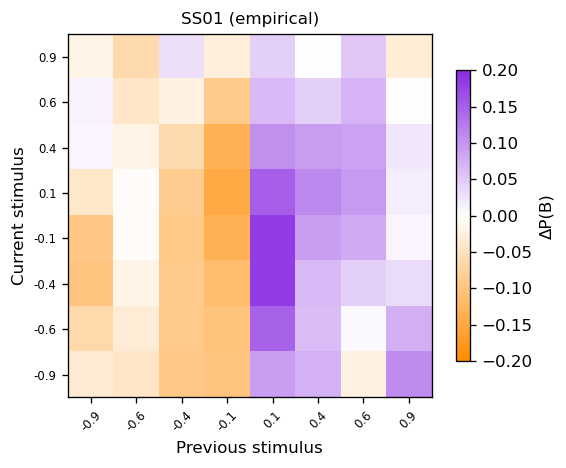

In [52]:
n_animals = len(animal_dfs)
fig, axes = plt.subplots(1, n_animals, figsize=(5 * n_animals, 4))
if n_animals == 1:
    axes = [axes]

for ax, (aid, df) in zip(axes, animal_dfs.items()):
    s = df['stim_relative'].values
    chooseB = df['choice'].values
    reward = df['correct'].values
    no_resp = df['No_response'].values
    not_block = df['is_not_start_of_block'].values

    um, cm = post_correct_update_matrix(s, chooseB, reward, no_resp, not_block)
    plot_update_matrix_quick(um, title=f'{aid} (empirical)', ax=ax)

plt.tight_layout()
plt.show()

## 5. Run 2-Fold CV × 64 Seeds

This is the heavy computation. For each animal, each seed, each model:
- 2-fold CV with grid search (8000 parameter combos per fold)
- Store the average test error across folds

**Expected runtime**: Depends on number of trials and parallelisation.
With `joblib` and ~8 cores, each seed takes ~2–5 min per model.
64 seeds × 2 models ≈ 4–10 hours per animal.

Consider reducing `N_SEEDS` to 8 for a quick check first.

In [53]:
# ── Quick-run toggle ──────────────────────────────────────────────────────────
QUICK_RUN = True  # Set False for full 64-seed run

if QUICK_RUN:
    N_SEEDS_RUN = 8
    print(f"QUICK RUN: {N_SEEDS_RUN} seeds (set QUICK_RUN=False for full {N_SEEDS})")
else:
    N_SEEDS_RUN = N_SEEDS
    print(f"FULL RUN: {N_SEEDS_RUN} seeds")

QUICK RUN: 8 seeds (set QUICK_RUN=False for full 64)


In [54]:
def run_cv_one_seed(df, model_func, model_name, seed,
                    sigma_noise_values, A_repulsion_values,
                    x_axis_values, y_axis_values,
                    k=2, fit_with='conditional', mode_pre='simulated'):
    """
    Run one k-fold CV iteration for a given model and seed.
    
    Returns dict with:
        - 'avg_test_error': mean test error across folds
        - 'test_errors': list of per-fold test errors
        - 'best_params': per-fold optimal parameters
        - 'model': model name
        - 'seed': seed used
    """
    try:
        results = k_fold_CV(
            df=df,
            model=model_func,
            func=post_correct_update_matrix,
            sigma_noise_values=sigma_noise_values,
            A_repulsion_values=A_repulsion_values,
            x_axis_values=x_axis_values,
            y_axis_values=y_axis_values,
            seed=seed,
            k=k,
            mode_pre=mode_pre,
            fit_with=fit_with,
            show_progress=False,
        )
        # results[1] = test_errors_list (one per fold)
        test_errors = results[1]
        avg_error = np.mean(test_errors)

        return {
            'avg_test_error': avg_error,
            'test_errors': test_errors,
            'best_params': results[0],  # optimal_params_list (per fold)
            'model': model_name,
            'seed': seed,
        }
    except Exception as e:
        print(f"  ERROR [{model_name}, seed={seed}]: {e}")
        return {
            'avg_test_error': np.nan,
            'test_errors': [],
            'best_params': None,
            'model': model_name,
            'seed': seed,
        }

In [ ]:
# ── Main CV loop ──────────────────────────────────────────────────────────────
all_results = {}  # {animal_id: list of result dicts}

for animal in animals:
    aid = animal.animal_id
    df = animal_dfs[aid]
    print(f"\n{'='*60}")
    print(f"Animal: {aid} ({len(df)} trials, {df['block'].nunique()} blocks)")
    print(f"{'='*60}")

    animal_results = []
    t_start = time.time()

    for seed_idx in tqdm(range(N_SEEDS_RUN), desc=f"{aid}"):
        seed = seed_idx + 1  # seeds 1..N_SEEDS_RUN

        # ── BE ────────────────────────────────────────────────────────────
        be_result = run_cv_one_seed(
            df, BE_model, 'BE', seed,
            sigma_noise_values=SIGMA_NOISE_VALUES,
            A_repulsion_values=A_REPULSION_VALUES,
            x_axis_values=BE_ETA_RELAX_VALUES,     # x_axis for BE
            y_axis_values=BE_ETA_LEARNING_VALUES,   # y_axis for BE
            k=N_FOLDS, fit_with=FIT_WITH, mode_pre=MODE_PRE,
        )
        animal_results.append(be_result)

        # ── SC ────────────────────────────────────────────────────────────
        sc_result = run_cv_one_seed(
            df, SC_model, 'SC', seed,
            sigma_noise_values=SIGMA_NOISE_VALUES,
            A_repulsion_values=A_REPULSION_VALUES,
            x_axis_values=SC_SIGMA_UPDATE_VALUES,   # x_axis for SC
            y_axis_values=SC_GAMMA_VALUES,           # y_axis for SC
            k=N_FOLDS, fit_with=FIT_WITH, mode_pre=MODE_PRE,
        )
        animal_results.append(sc_result)

    elapsed = time.time() - t_start
    print(f"  Done in {elapsed/60:.1f} min")

    all_results[aid] = animal_results

    # ── Save incrementally ────────────────────────────────────────────────
    with open(OUTPUT_DIR / f'cv_results_{aid}.pkl', 'wb') as f:
        pickle.dump(animal_results, f)
    print(f"  Saved to {OUTPUT_DIR / f'cv_results_{aid}.pkl'}")


Animal: SS01 (4984 trials, 10 blocks)


SS01:   0%|          | 0/8 [00:00<?, ?it/s]

## 6. Assemble Results into Long-Form DataFrame

In [38]:
def results_to_long_df(all_results):
    """
    Convert the nested results dict into a tidy long-form DataFrame.
    """
    rows = []
    for aid, results_list in all_results.items():
        for r in results_list:
            rows.append({
                'Participant_ID': aid,
                'Model': r['model'],
                'Seed': r['seed'],
                'Avg_Test_Error': r['avg_test_error'],
            })
    return pd.DataFrame(rows)


long_df = results_to_long_df(all_results)
print(f"Long DataFrame: {len(long_df)} rows")
print(long_df.groupby(['Participant_ID', 'Model'])['Avg_Test_Error'].agg(['mean', 'std', 'count']))

Long DataFrame: 112 rows
                          mean       std  count
Participant_ID Model                           
SS01           BE     0.081060  0.011680      8
               SC     0.087075  0.018790      8
SS04           BE     0.070636  0.010098      8
               SC     0.059509  0.015787      8
SS05           BE     0.096927  0.024230      8
               SC     0.115369  0.026576      8
SS06           BE     0.068056  0.015122      8
               SC     0.089710  0.017661      8
SS07           BE     0.060597  0.010437      8
               SC     0.046968  0.008676      8
SS08           BE     0.075098  0.009690      8
               SC     0.113426  0.014192      8
SS09           BE     0.148355  0.025666      8
               SC     0.173027  0.046771      8


## 7. Model Comparison: ANOVA per Animal

Following the manuscript: for each animal, compare the distribution of
64 test errors between BE and SC using one-way ANOVA.
If p < 0.05, the model with lower mean error wins.

In [39]:
comparison_results = []

for aid in animal_dfs.keys():
    be_errors = long_df.loc[
        (long_df['Participant_ID'] == aid) & (long_df['Model'] == 'BE'),
        'Avg_Test_Error'
    ].dropna().values

    sc_errors = long_df.loc[
        (long_df['Participant_ID'] == aid) & (long_df['Model'] == 'SC'),
        'Avg_Test_Error'
    ].dropna().values

    if len(be_errors) < 2 or len(sc_errors) < 2:
        print(f"  {aid}: insufficient data for ANOVA")
        continue

    # One-way ANOVA
    F_stat, p_value = sp_stats.f_oneway(be_errors, sc_errors)

    be_mean = np.mean(be_errors)
    sc_mean = np.mean(sc_errors)

    if p_value < 0.05:
        winner = 'BE' if be_mean < sc_mean else 'SC'
    else:
        winner = 'Inconclusive'

    comparison_results.append({
        'Participant_ID': aid,
        'BE_mean_error': be_mean,
        'SC_mean_error': sc_mean,
        'F_stat': F_stat,
        'p_value': p_value,
        'Winner': winner,
    })

    print(f"  {aid}: BE={be_mean:.4f}  SC={sc_mean:.4f}  "
          f"F={F_stat:.2f}  p={p_value:.4f}  → {winner}")

comparison_df = pd.DataFrame(comparison_results)
comparison_df

  SS01: BE=0.0811  SC=0.0871  F=0.59  p=0.4547  → Inconclusive
  SS04: BE=0.0706  SC=0.0595  F=2.82  p=0.1153  → Inconclusive
  SS05: BE=0.0969  SC=0.1154  F=2.10  p=0.1690  → Inconclusive
  SS06: BE=0.0681  SC=0.0897  F=6.94  p=0.0196  → BE
  SS07: BE=0.0606  SC=0.0470  F=8.07  p=0.0131  → SC
  SS08: BE=0.0751  SC=0.1134  F=39.80  p=0.0000  → BE
  SS09: BE=0.1484  SC=0.1730  F=1.71  p=0.2119  → Inconclusive


,Participant_ID,BE_mean_error,SC_mean_error,F_stat,p_value,Winner
0,SS01,0.081060,0.087075,0.591410,0.454653,Inconclusive
1,SS04,0.070636,0.059509,2.820202,0.115254,Inconclusive
2,SS05,0.096927,0.115369,2.103819,0.168966,Inconclusive
3,SS06,0.068056,0.089710,6.939089,0.019624,BE
4,SS07,0.060597,0.046968,8.066615,0.013101,SC
5,SS08,0.075098,0.113426,39.796480,0.000019,BE
6,SS09,0.148355,0.173027,1.710919,0.211937,Inconclusive


## 8. Visualisation

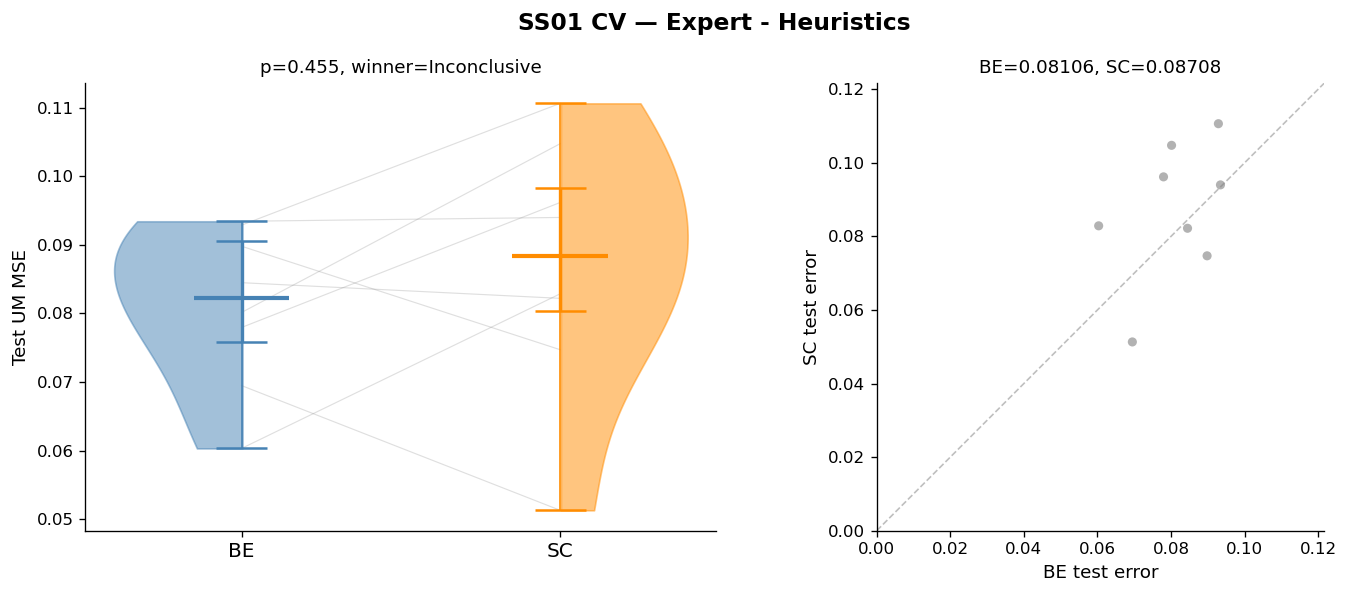

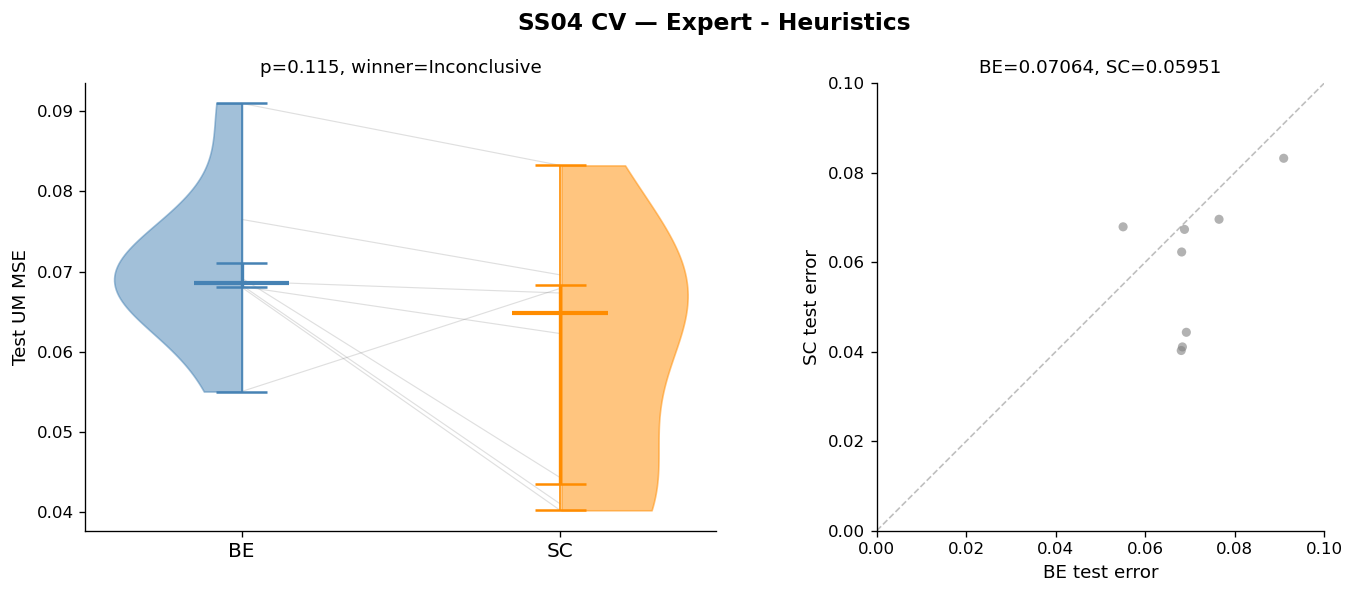

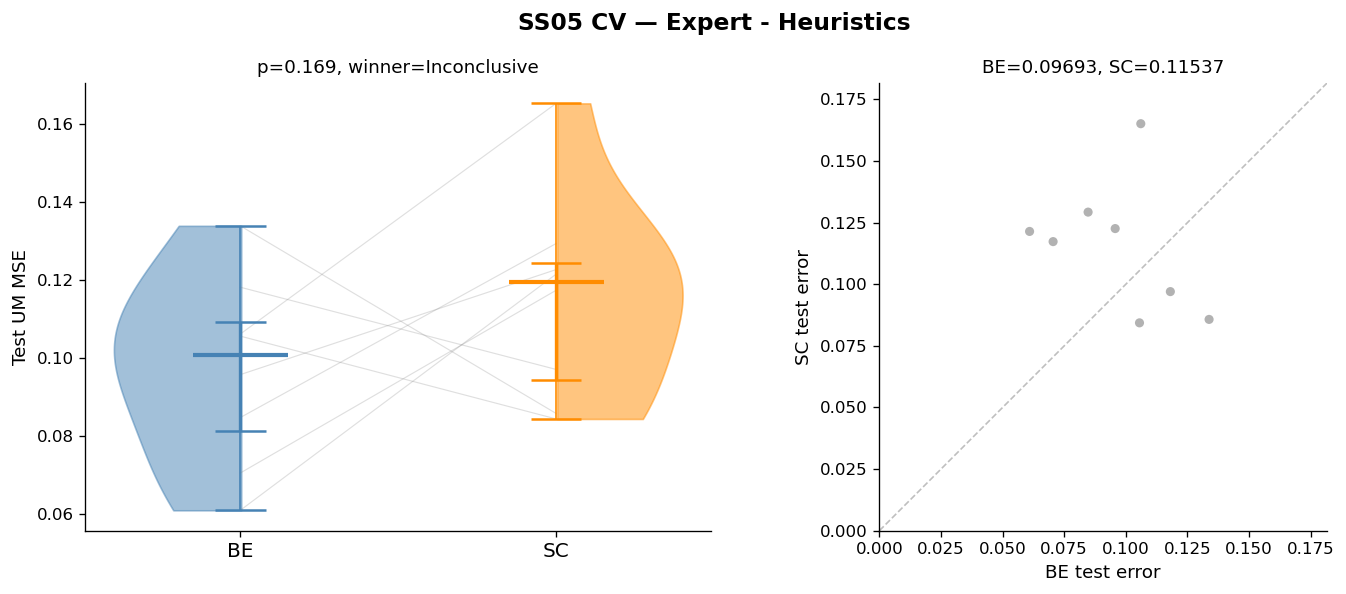

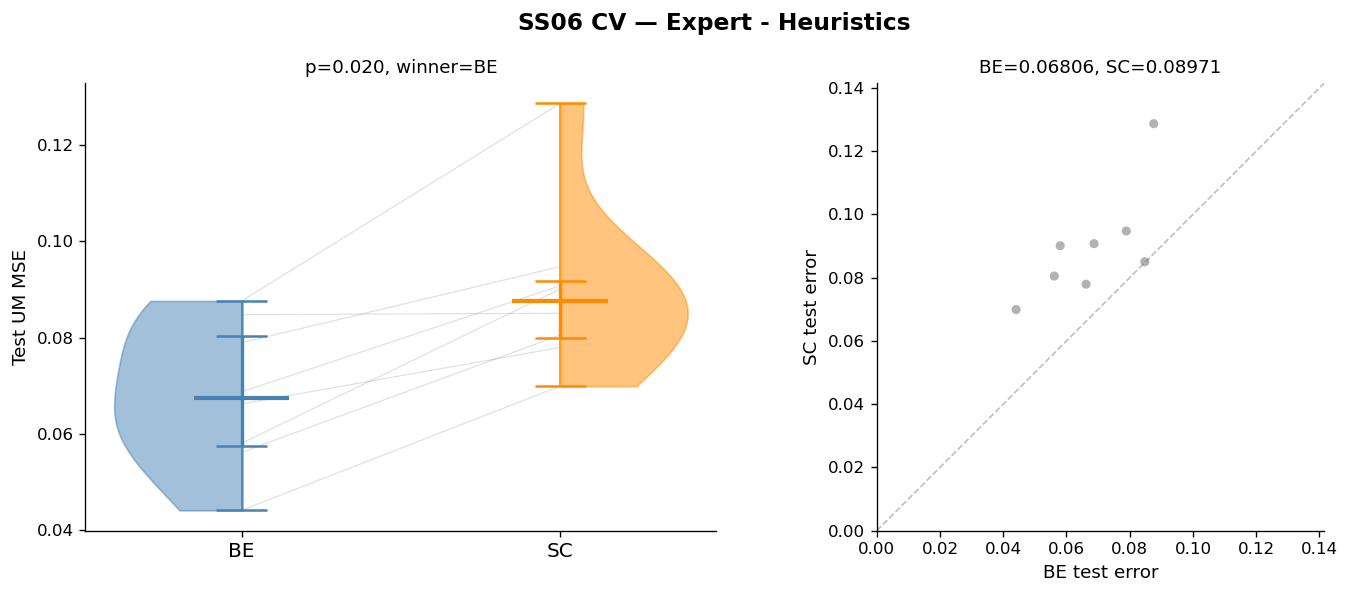

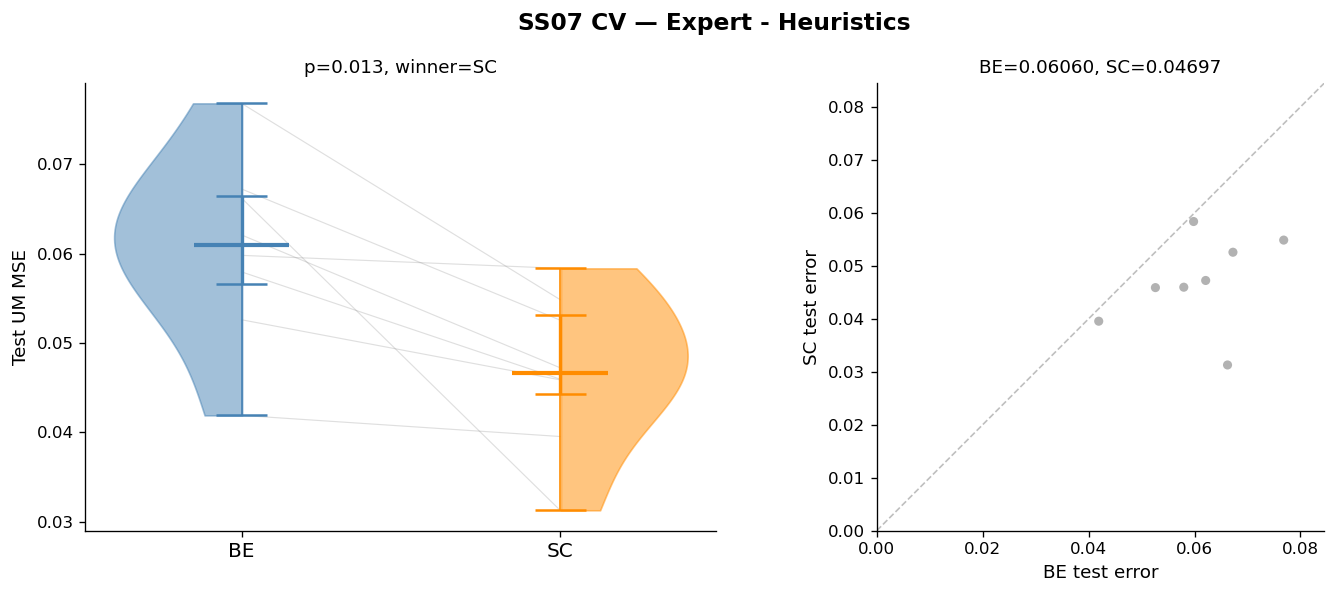

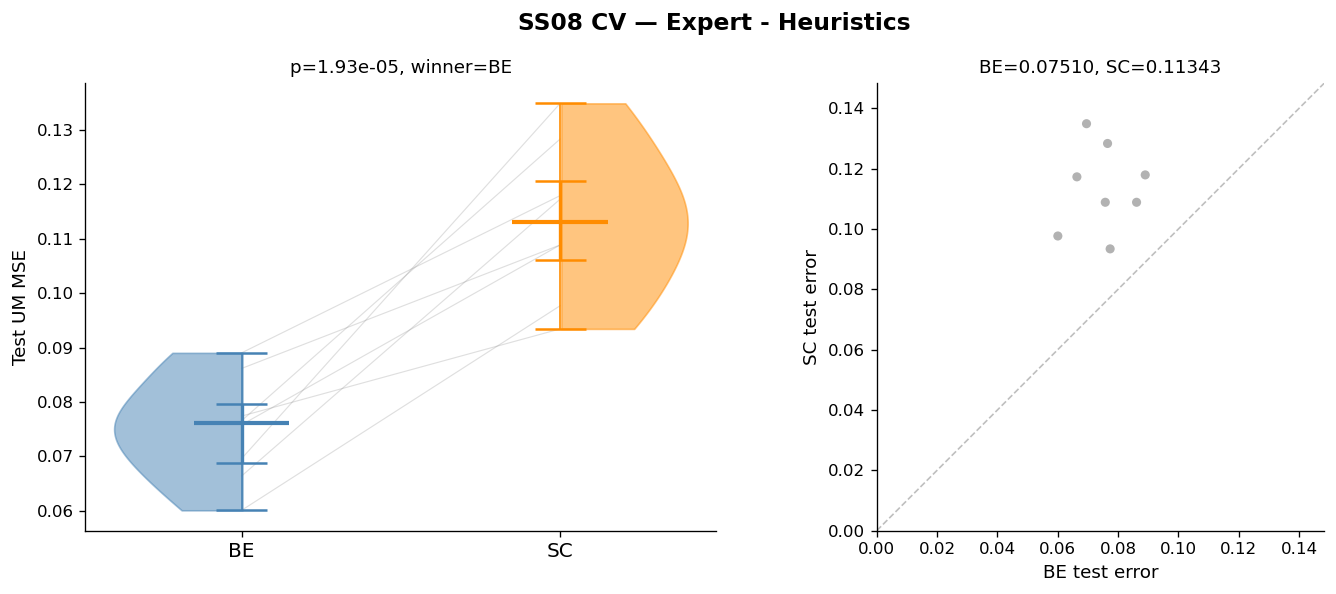

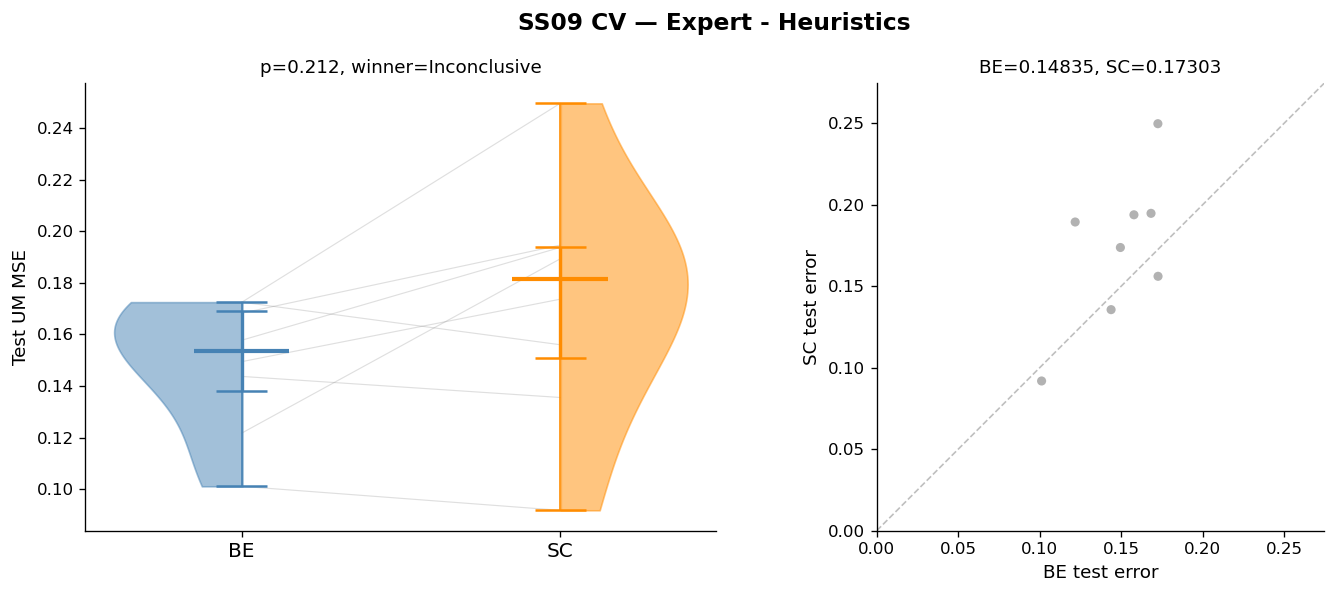

In [40]:
# ── 8a. Per-animal: split violin + paired scatter (manuscript style) ──────────

animal_ids = list(animal_dfs.keys())

for aid in animal_ids:
    sub = long_df[long_df['Participant_ID'] == aid].copy()
    be_sub = sub[sub['Model'] == 'BE'].sort_values('Seed').reset_index(drop=True)
    sc_sub = sub[sub['Model'] == 'SC'].sort_values('Seed').reset_index(drop=True)

    be_vals = be_sub['Avg_Test_Error'].dropna().values
    sc_vals = sc_sub['Avg_Test_Error'].dropna().values

    # Match seeds for paired lines
    paired_seeds = set(be_sub['Seed'].values) & set(sc_sub['Seed'].values)
    be_paired = be_sub[be_sub['Seed'].isin(paired_seeds)].set_index('Seed')['Avg_Test_Error']
    sc_paired = sc_sub[sc_sub['Seed'].isin(paired_seeds)].set_index('Seed')['Avg_Test_Error']
    common_seeds = sorted(paired_seeds)
    be_p = np.array([be_paired[s] for s in common_seeds])
    sc_p = np.array([sc_paired[s] for s in common_seeds])

    # Stats
    row = comparison_df[comparison_df['Participant_ID'] == aid]
    if len(row) > 0:
        p_val = row.iloc[0]['p_value']
        winner = row.iloc[0]['Winner']
    else:
        from scipy.stats import f_oneway
        _, p_val = f_oneway(be_vals, sc_vals)
        winner = 'BE' if np.mean(be_vals) < np.mean(sc_vals) else 'SC'

    p_str = f'p={p_val:.2e}' if p_val < 0.001 else f'p={p_val:.3f}'

    # ── Figure ────────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # ── Left: split violin with paired lines ──────────────────────────────
    # Violins
    vp_be = ax1.violinplot(be_vals, positions=[0], showextrema=False,
                            showmedians=False, widths=0.8)
    vp_sc = ax1.violinplot(sc_vals, positions=[1], showextrema=False,
                            showmedians=False, widths=0.8)

    for body in vp_be['bodies']:
        m = np.mean(body.get_paths()[0].vertices[:, 0])
        body.get_paths()[0].vertices[:, 0] = np.clip(
            body.get_paths()[0].vertices[:, 0], -np.inf, m)
        body.set_facecolor('steelblue')
        body.set_alpha(0.5)
        body.set_edgecolor('steelblue')

    for body in vp_sc['bodies']:
        m = np.mean(body.get_paths()[0].vertices[:, 0])
        body.get_paths()[0].vertices[:, 0] = np.clip(
            body.get_paths()[0].vertices[:, 0], m, np.inf)
        body.set_facecolor('darkorange')
        body.set_alpha(0.5)
        body.set_edgecolor('darkorange')

    # Paired lines
    for b, s in zip(be_p, sc_p):
        ax1.plot([0, 1], [b, s], color='grey', alpha=0.25, linewidth=0.7)

    # Summary stats (median + IQR)
    for pos, vals, color in [(0, be_vals, 'steelblue'), (1, sc_vals, 'darkorange')]:
        q25, med, q75 = np.percentile(vals, [25, 50, 75])
        ax1.hlines(med, pos - 0.15, pos + 0.15, color=color, linewidth=2.5)
        ax1.vlines(pos, q25, q75, color=color, linewidth=2)
        ax1.hlines([q25, q75], pos - 0.08, pos + 0.08, color=color, linewidth=1.5)
        # whiskers
        lo = np.min(vals)
        hi = np.max(vals)
        ax1.vlines(pos, lo, q25, color=color, linewidth=1, linestyle='-')
        ax1.vlines(pos, q75, hi, color=color, linewidth=1, linestyle='-')
        ax1.hlines([lo, hi], pos - 0.08, pos + 0.08, color=color, linewidth=1.5)

    ax1.set_xticks([0, 1])
    ax1.set_xticklabels(['BE', 'SC'], fontsize=12)
    ax1.set_ylabel('Test UM MSE', fontsize=11)
    ax1.set_title(f'{p_str}, winner={winner}', fontsize=11)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # ── Right: paired scatter ─────────────────────────────────────────────
    ax2.scatter(be_p, sc_p, c='grey', alpha=0.6, s=30, edgecolors='none')

    # Identity line
    all_vals = np.concatenate([be_p, sc_p])
    lo, hi = np.min(all_vals) * 0.9, np.max(all_vals) * 1.1
    ax2.plot([0, hi], [0, hi], '--', color='grey', alpha=0.5, linewidth=1)
    ax2.set_xlim(0, hi)
    ax2.set_ylim(0, hi)
    ax2.set_xlabel('BE test error', fontsize=11)
    ax2.set_ylabel('SC test error', fontsize=11)
    ax2.set_title(f'BE={np.mean(be_p):.5f}, SC={np.mean(sc_p):.5f}', fontsize=11)
    ax2.set_aspect('equal')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    fig.suptitle(f'{aid} CV — Expert - Heuristics', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'cv_comparison_{aid}.png', dpi=200, bbox_inches='tight')
    plt.show()


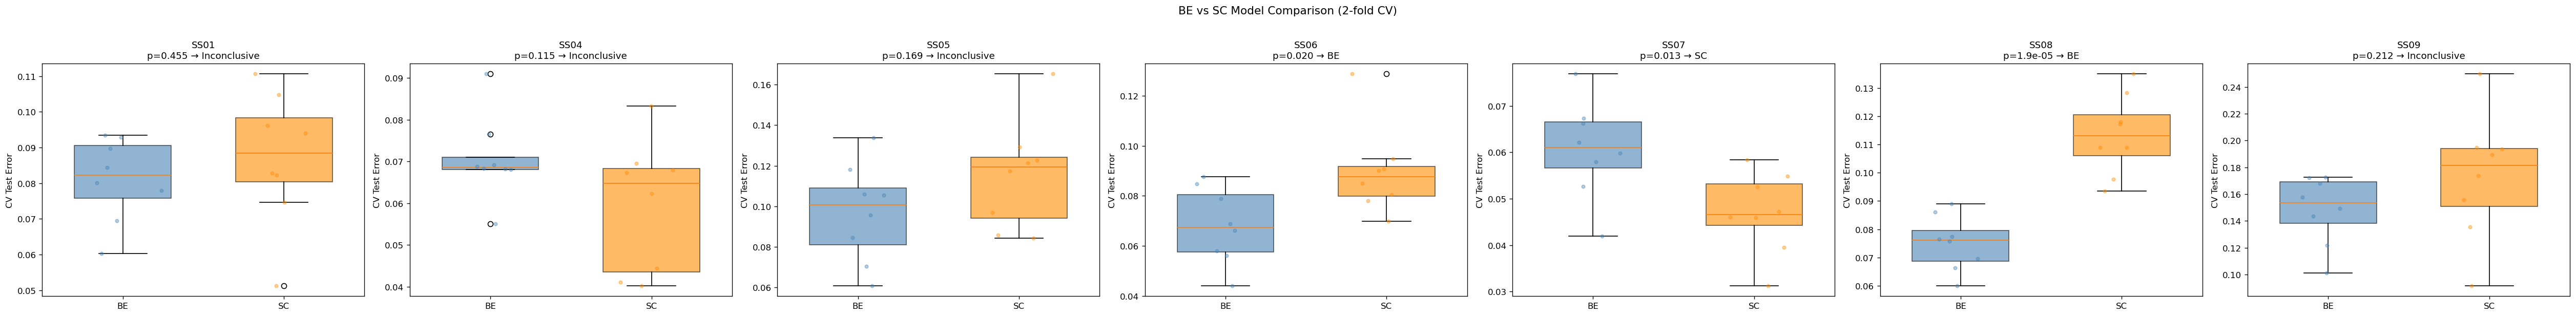

In [41]:
# ── 8a. Per-animal seed-level error distributions ────────────────────────────

animal_ids = list(animal_dfs.keys())
n_animals = len(animal_ids)

fig, axes = plt.subplots(1, n_animals, figsize=(6 * n_animals, 5), squeeze=False)
axes = axes[0]

for ax, aid in zip(axes, animal_ids):
    sub = long_df[long_df['Participant_ID'] == aid]
    be_vals = sub.loc[sub['Model'] == 'BE', 'Avg_Test_Error'].dropna()
    sc_vals = sub.loc[sub['Model'] == 'SC', 'Avg_Test_Error'].dropna()

    positions = [0, 1]
    bp = ax.boxplot([be_vals, sc_vals], positions=positions, widths=0.6,
                    patch_artist=True, showfliers=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('darkorange')
    bp['boxes'][1].set_alpha(0.6)

    # Overlay individual seeds
    jitter = 0.1
    ax.scatter(np.random.normal(0, jitter, len(be_vals)), be_vals,
               c='steelblue', alpha=0.4, s=15, zorder=3)
    ax.scatter(np.random.normal(1, jitter, len(sc_vals)), sc_vals,
               c='darkorange', alpha=0.4, s=15, zorder=3)

    # Significance annotation
    row = comparison_df[comparison_df['Participant_ID'] == aid]
    if len(row) > 0:
        p = row.iloc[0]['p_value']
        winner = row.iloc[0]['Winner']
        sig_str = f'p={p:.3f}' if p >= 0.001 else f'p={p:.1e}'
        ax.set_title(f'{aid}\n{sig_str} → {winner}', fontsize=11)
    else:
        ax.set_title(aid)

    ax.set_xticks(positions)
    ax.set_xticklabels(['BE', 'SC'])
    ax.set_ylabel('CV Test Error')

plt.suptitle('BE vs SC Model Comparison (2-fold CV)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cv_comparison_boxplots.png', dpi=200, bbox_inches='tight')
plt.show()

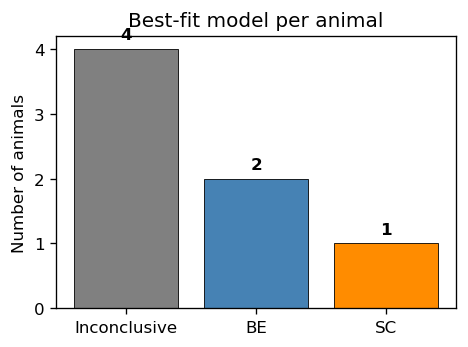

In [42]:
# ── 8b. Winner summary bar chart ─────────────────────────────────────────────
if len(comparison_df) > 0:
    winner_counts = comparison_df['Winner'].value_counts()
    colors = {'BE': 'steelblue', 'SC': 'darkorange', 'Inconclusive': 'grey'}
    
    fig, ax = plt.subplots(figsize=(4, 3))
    bars = ax.bar(
        winner_counts.index,
        winner_counts.values,
        color=[colors.get(w, 'grey') for w in winner_counts.index],
        edgecolor='black', linewidth=0.5
    )
    ax.set_ylabel('Number of animals')
    ax.set_title('Best-fit model per animal')
    for bar, val in zip(bars, winner_counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                str(val), ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'winner_summary.png', dpi=200, bbox_inches='tight')
    plt.show()

## 9. Best-Fit Parameters & Model Update Matrices

For each animal, take the winning model's best parameters
(from the seed with lowest avg test error), simulate, and compare
the model's update matrix to the empirical one.

In [23]:
from Old.BE_Generative import BE_model as BE_model_gen
from Old.SC_Generative import SC_model as SC_model_gen
from Old.BE import Noise_generator, Delta_repulsion
from scipy.stats import uniform as sp_uniform


def get_best_seed_params(animal_results, model_name):
    """
    From all CV results for one animal and model,
    find the seed with the lowest avg test error
    and return its best_params from the first fold.
    """
    model_runs = [r for r in animal_results if r['model'] == model_name]
    valid = [r for r in model_runs if not np.isnan(r['avg_test_error'])]
    if len(valid) == 0:
        return None, None
    best_run = min(valid, key=lambda r: r['avg_test_error'])
    # best_params is a list of [sigma_noise, A_repulsion, x_val, y_val] per fold
    # Take the first fold's params as representative
    params = best_run['best_params']
    if params is not None and len(params) > 0:
        return params[0], best_run['seed']
    return None, None


def simulate_model_um(df, model_name, params, seed):
    """
    Simulate model with given params on the animal's stimulus sequence,
    then compute update matrix.
    
    params: [sigma_noise, A_repulsion, x_axis_val, y_axis_val]
        BE: x_axis=eta_relax, y_axis=eta_learning
        SC: x_axis=sigma_update, y_axis=gamma
    """
    s = df['stim_relative'].values
    no_response = df['No_response'].values.astype(bool)
    not_blockstart = df['is_not_start_of_block'].values.astype(bool)
    categories = np.where(s > 0, 1, 0)

    sigma_noise, A_repulsion, x_val, y_val = params

    # Stimulus space
    max_range = 1 + 6 * sigma_noise + 2 * A_repulsion * (1 + 6 * sigma_noise)
    min_range = -1 - 6 * sigma_noise - 2 * A_repulsion * (1 + 6 * sigma_noise)
    num_points = round((max_range - min_range) * 1000)
    x = np.linspace(min_range, max_range, num_points)

    # Noisy perception
    s_tilde = s + Noise_generator(len(s), seed, sigma_noise)
    s_hat = Delta_repulsion(A_repulsion, s_tilde)

    if model_name == 'BE':
        y = sp_uniform.pdf(x, loc=min_range, scale=max_range - min_range)
        model_um, model_cm = BE_model(
            post_correct_update_matrix,
            x, y, s, s_hat, categories,
            sigma_noise, A_repulsion,
            y_val,   # eta_learning
            x_val,   # eta_relax
            no_response, not_blockstart, seed, 'simulated'
        )
    elif model_name == 'SC':
        y = None  # SC doesn't use y (boundary PDF)
        model_um, model_cm = SC_model(
            post_correct_update_matrix,
            x, None, s, s_hat, categories,
            sigma_noise, A_repulsion,
            y_val,   # gamma
            x_val,   # sigma_update
            no_response, not_blockstart, seed, 'simulated'
        )
    else:
        raise ValueError(f"Unknown model: {model_name}")

    return model_um, model_cm

  SS01 BE params: σ=0.133, A=0.250, η_relax=0.050, η_learn=0.100
  SS01 SC params: σ=0.133, A=0.000, σ_update=1.000, γ=0.743


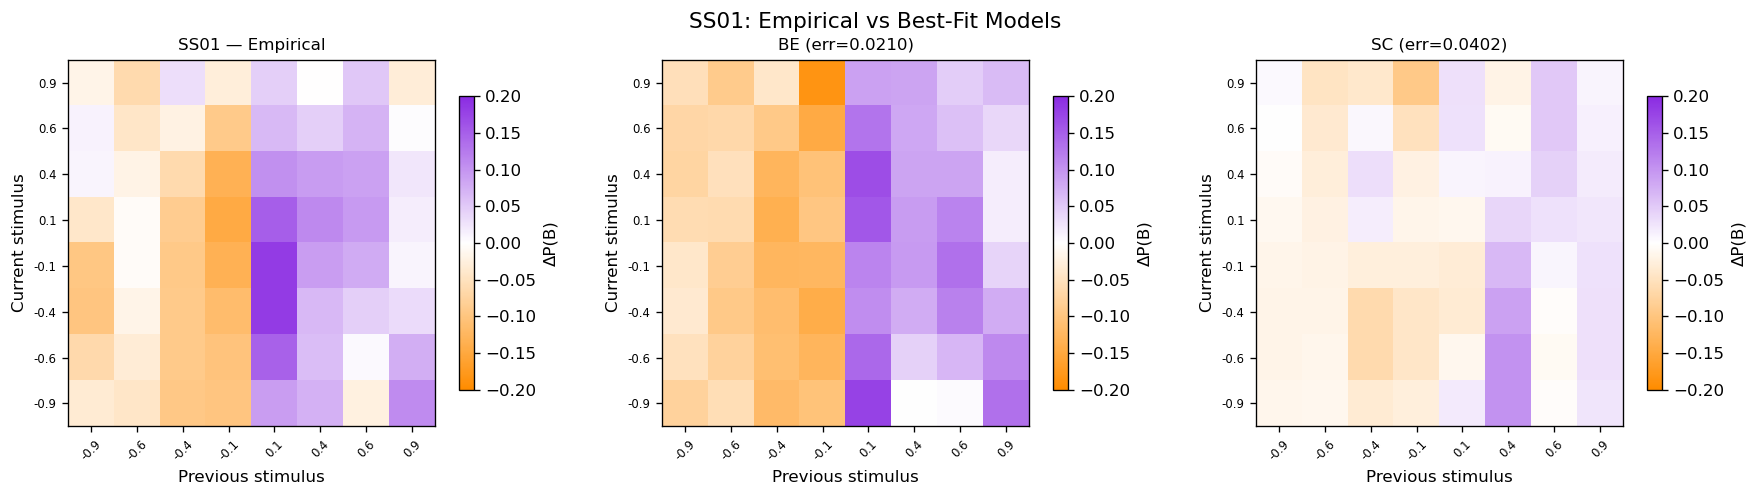

  SS04 BE params: σ=0.050, A=0.000, η_relax=0.050, η_learn=0.100
  SS04 SC params: σ=0.217, A=0.250, σ_update=0.100, γ=0.357


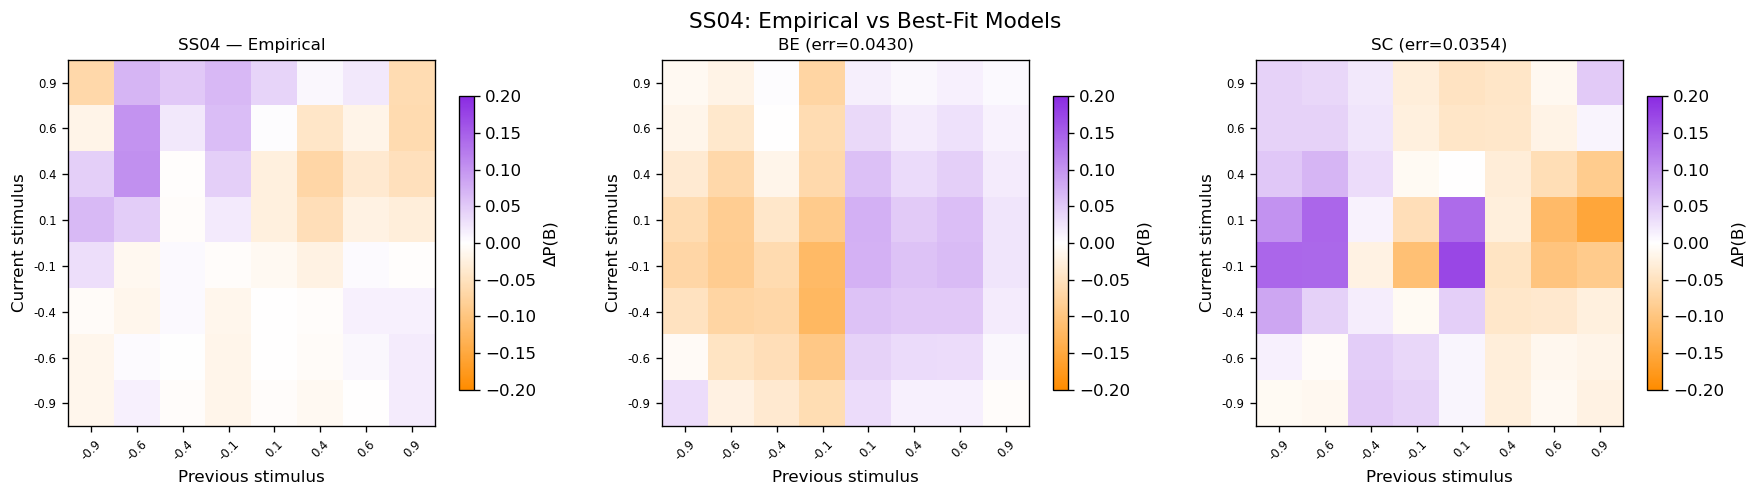

  SS05 BE params: σ=0.050, A=0.000, η_relax=0.167, η_learn=0.329
  SS05 SC params: σ=0.300, A=0.000, σ_update=0.700, γ=0.614


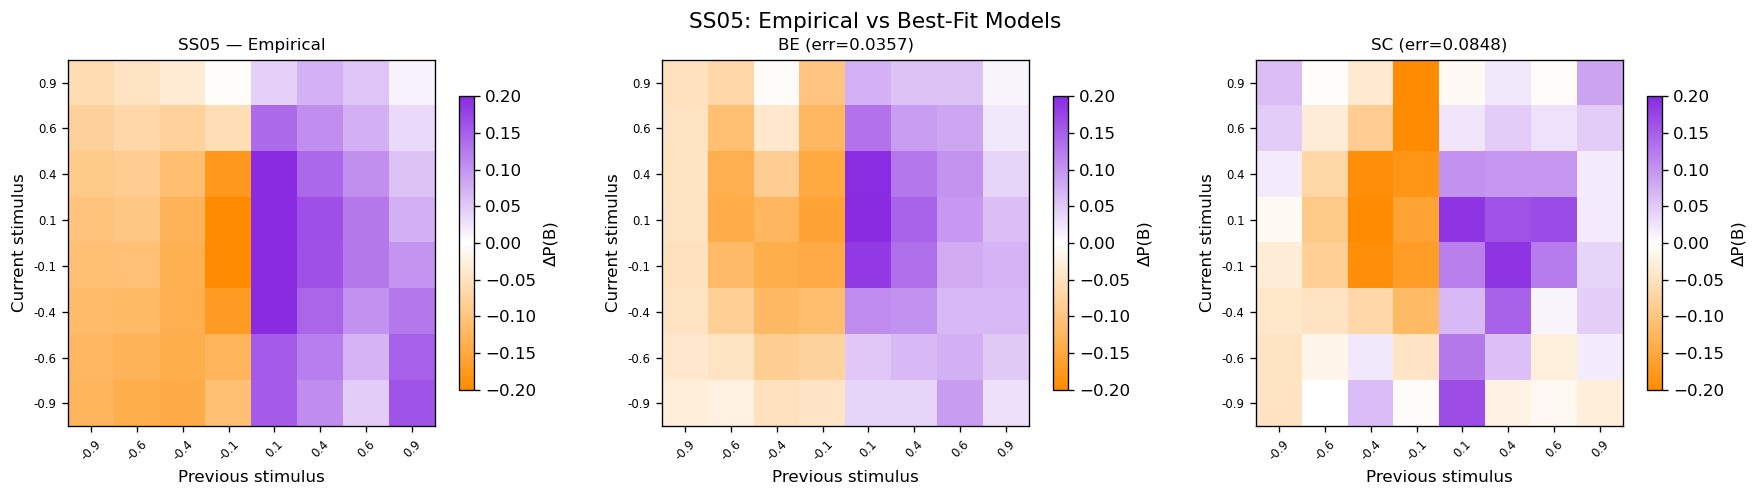

  SS06 BE params: σ=0.050, A=0.000, η_relax=0.050, η_learn=0.443
  SS06 SC params: σ=0.133, A=0.000, σ_update=0.700, γ=0.486


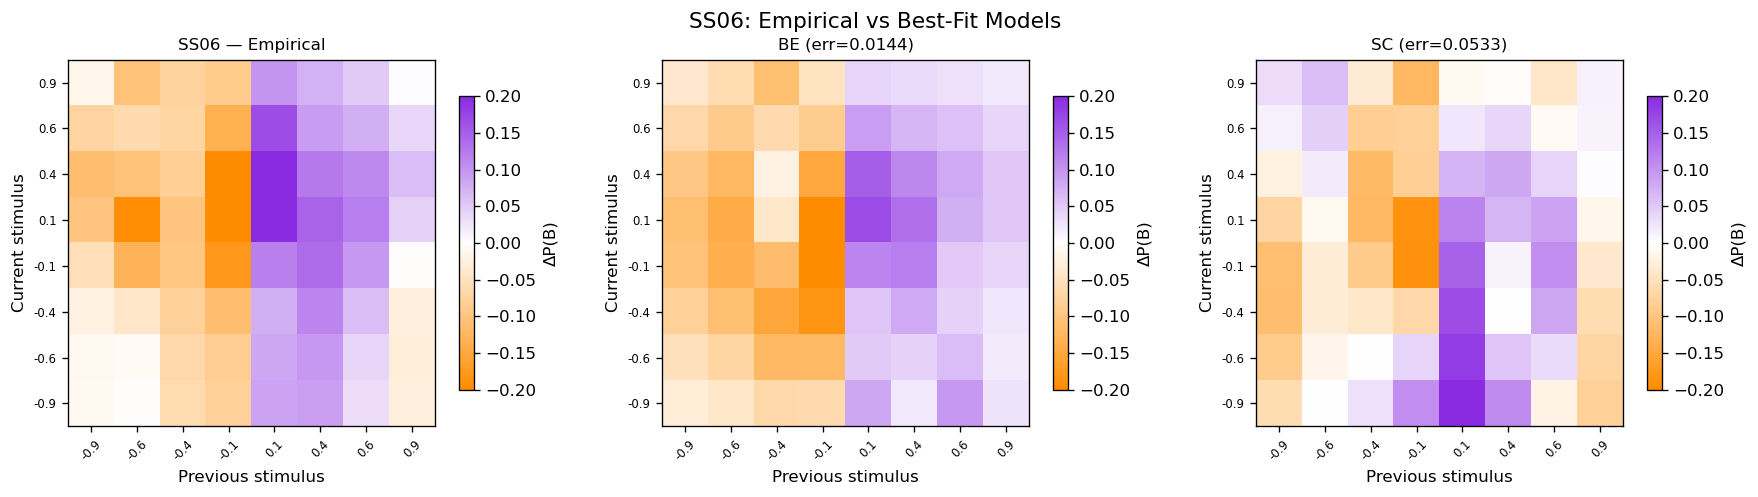

  SS07 BE params: σ=0.050, A=0.000, η_relax=0.050, η_learn=0.100
  SS07 SC params: σ=0.300, A=0.000, σ_update=0.100, γ=1.000


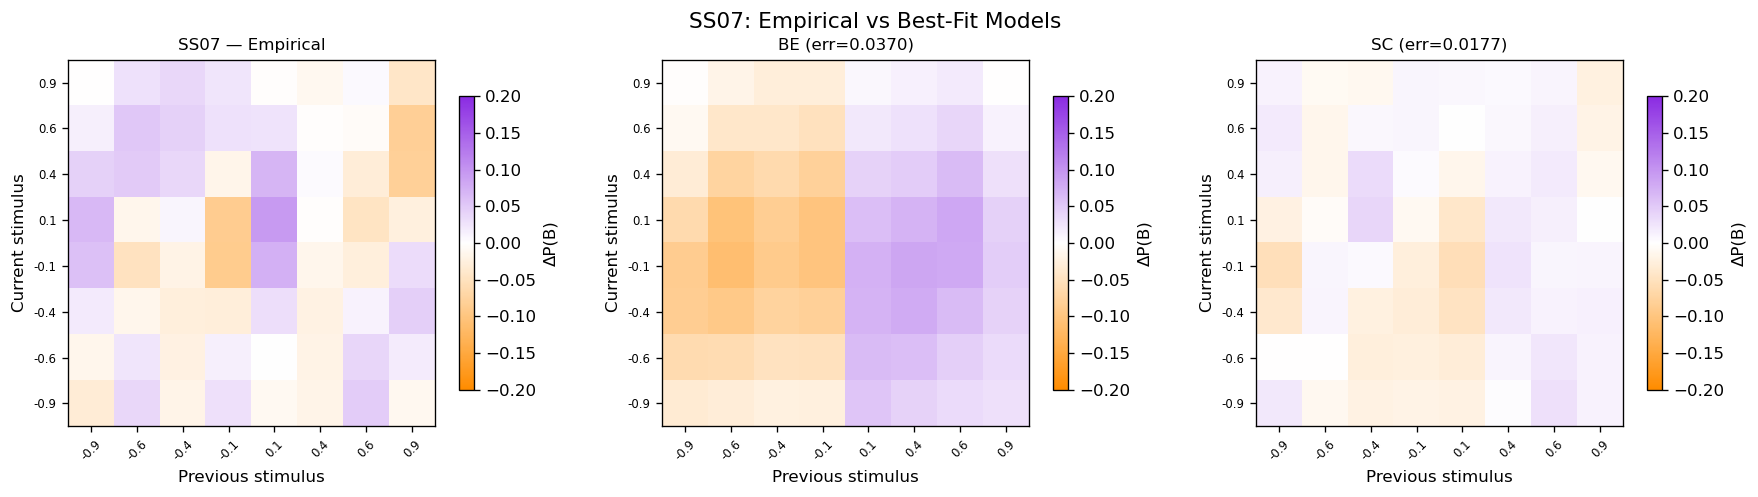

  SS08 BE params: σ=0.050, A=0.000, η_relax=0.050, η_learn=0.214
  SS08 SC params: σ=0.050, A=0.000, σ_update=0.700, γ=0.614


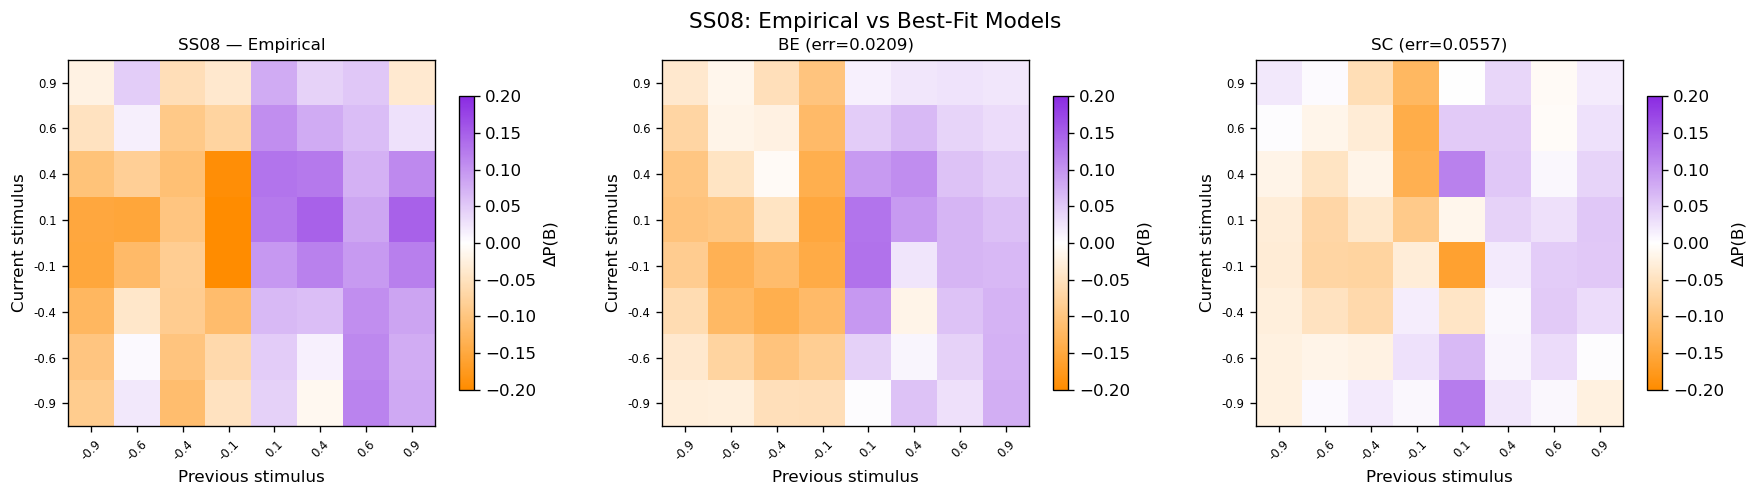

  SS09 BE params: σ=0.050, A=0.000, η_relax=0.050, η_learn=0.443
  SS09 SC params: σ=0.217, A=0.250, σ_update=0.700, γ=0.486


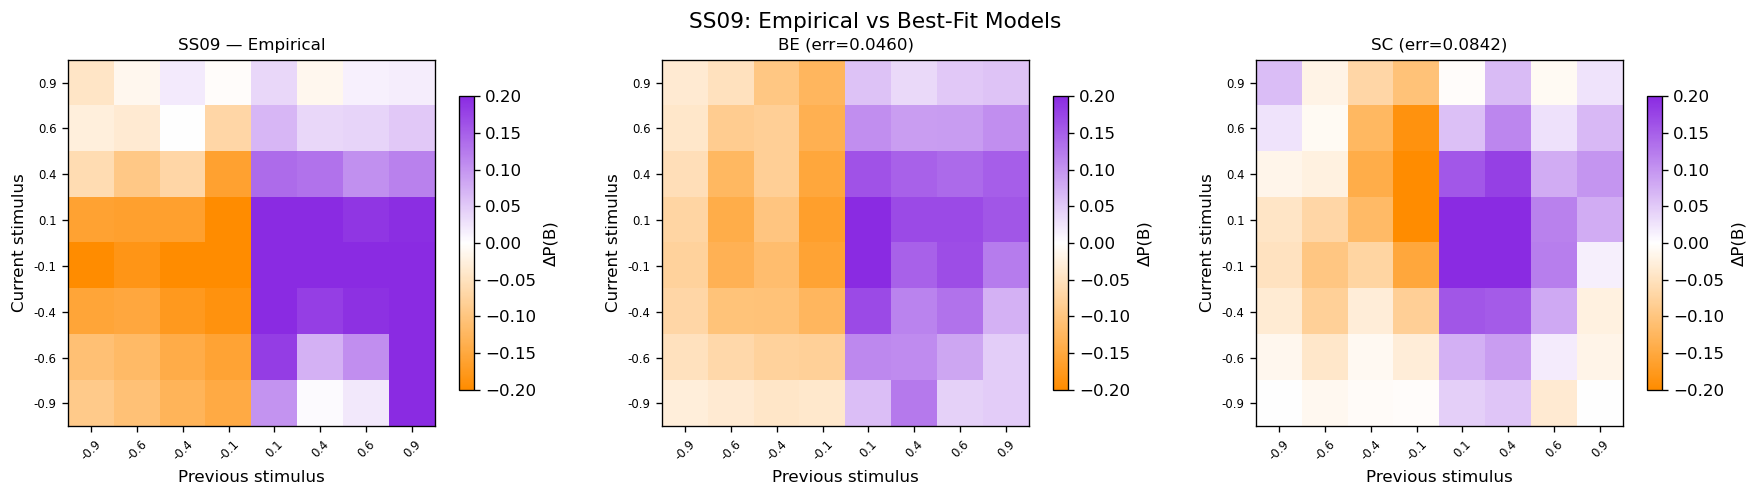

In [24]:
# ── Plot empirical vs best-fit model update matrices ──────────────────────────

for aid in animal_dfs.keys():
    df = animal_dfs[aid]
    results_list = all_results[aid]

    # Empirical
    s = df['stim_relative'].values
    chooseB = df['choice'].values
    reward = df['correct'].values
    no_resp = df['No_response'].values
    not_block = df['is_not_start_of_block'].values
    emp_um, emp_cm = post_correct_update_matrix(s, chooseB, reward, no_resp, not_block)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Empirical
    plot_update_matrix_quick(emp_um, title=f'{aid} — Empirical', ax=axes[0])

    # BE best fit
    be_params, be_seed = get_best_seed_params(results_list, 'BE')
    if be_params is not None:
        be_um, _ = simulate_model_um(df, 'BE', be_params, be_seed)
        be_err = matrix_error(be_um, emp_um[::-1])  # note: old code reverses
        plot_update_matrix_quick(be_um[::-1], title=f'BE (err={be_err:.4f})', ax=axes[1])
        print(f"  {aid} BE params: σ={be_params[0]:.3f}, A={be_params[1]:.3f}, "
              f"η_relax={be_params[2]:.3f}, η_learn={be_params[3]:.3f}")
    else:
        axes[1].set_title('BE: no valid fit')

    # SC best fit
    sc_params, sc_seed = get_best_seed_params(results_list, 'SC')
    if sc_params is not None:
        sc_um, _ = simulate_model_um(df, 'SC', sc_params, sc_seed)
        sc_err = matrix_error(sc_um, emp_um[::-1])
        plot_update_matrix_quick(sc_um[::-1], title=f'SC (err={sc_err:.4f})', ax=axes[2])
        print(f"  {aid} SC params: σ={sc_params[0]:.3f}, A={sc_params[1]:.3f}, "
              f"σ_update={sc_params[2]:.3f}, γ={sc_params[3]:.3f}")
    else:
        axes[2].set_title('SC: no valid fit')

    plt.suptitle(f'{aid}: Empirical vs Best-Fit Models', fontsize=13)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'um_comparison_{aid}.png', dpi=200, bbox_inches='tight')
    plt.show()

## 10. Parameter Distributions Across Seeds

In [25]:
def extract_param_df(all_results):
    """
    Extract best parameters from each seed into a DataFrame.
    """
    rows = []
    for aid, results_list in all_results.items():
        for r in results_list:
            if r['best_params'] is None:
                continue
            for fold_idx, params in enumerate(r['best_params']):
                if params is None:
                    continue
                sigma_noise, A_repulsion, x_val, y_val = params
                row = {
                    'Participant_ID': aid,
                    'Model': r['model'],
                    'Seed': r['seed'],
                    'Fold': fold_idx,
                    'sigma_noise': sigma_noise,
                    'A_repulsion': A_repulsion,
                }
                if r['model'] == 'BE':
                    row['eta_relax'] = x_val
                    row['eta_learning'] = y_val
                else:
                    row['sigma_update'] = x_val
                    row['gamma'] = y_val
                rows.append(row)
    return pd.DataFrame(rows)


param_df = extract_param_df(all_results)
print(f"Parameter DataFrame: {len(param_df)} rows")
param_df.head(10)

Parameter DataFrame: 112 rows


,Participant_ID,Model,Seed,Fold,sigma_noise,A_repulsion,eta_relax,eta_learning,sigma_update,gamma
0,SS01,BE,1,0,0.050000,0.25,0.166667,0.100000,NaN,NaN
1,SS01,BE,1,1,0.050000,0.00,0.400000,0.328571,NaN,NaN
2,SS01,SC,1,0,0.133333,0.00,NaN,NaN,1.0,0.742857
3,SS01,SC,1,1,0.133333,0.50,NaN,NaN,1.0,0.614286
4,SS01,BE,2,0,0.133333,0.25,0.050000,0.100000,NaN,NaN
5,SS01,BE,2,1,0.133333,0.00,0.050000,0.100000,NaN,NaN
6,SS01,SC,2,0,0.050000,0.50,NaN,NaN,1.0,0.485714
7,SS01,SC,2,1,0.300000,0.25,NaN,NaN,0.7,0.485714
8,SS01,BE,3,0,0.050000,0.00,0.166667,0.100000,NaN,NaN
9,SS01,BE,3,1,0.133333,0.25,0.050000,0.100000,NaN,NaN


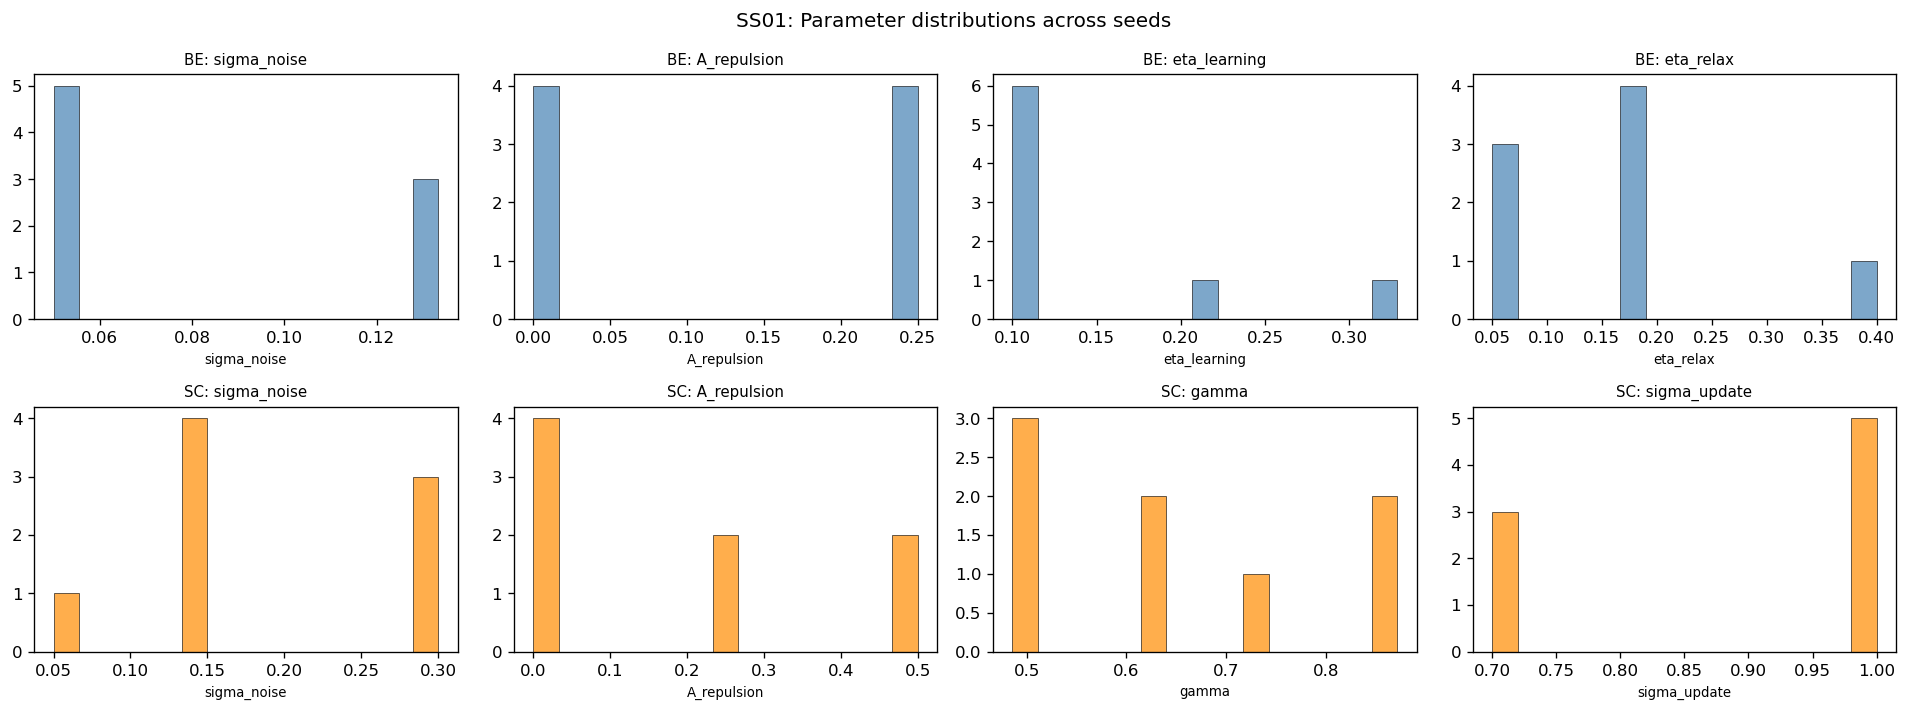

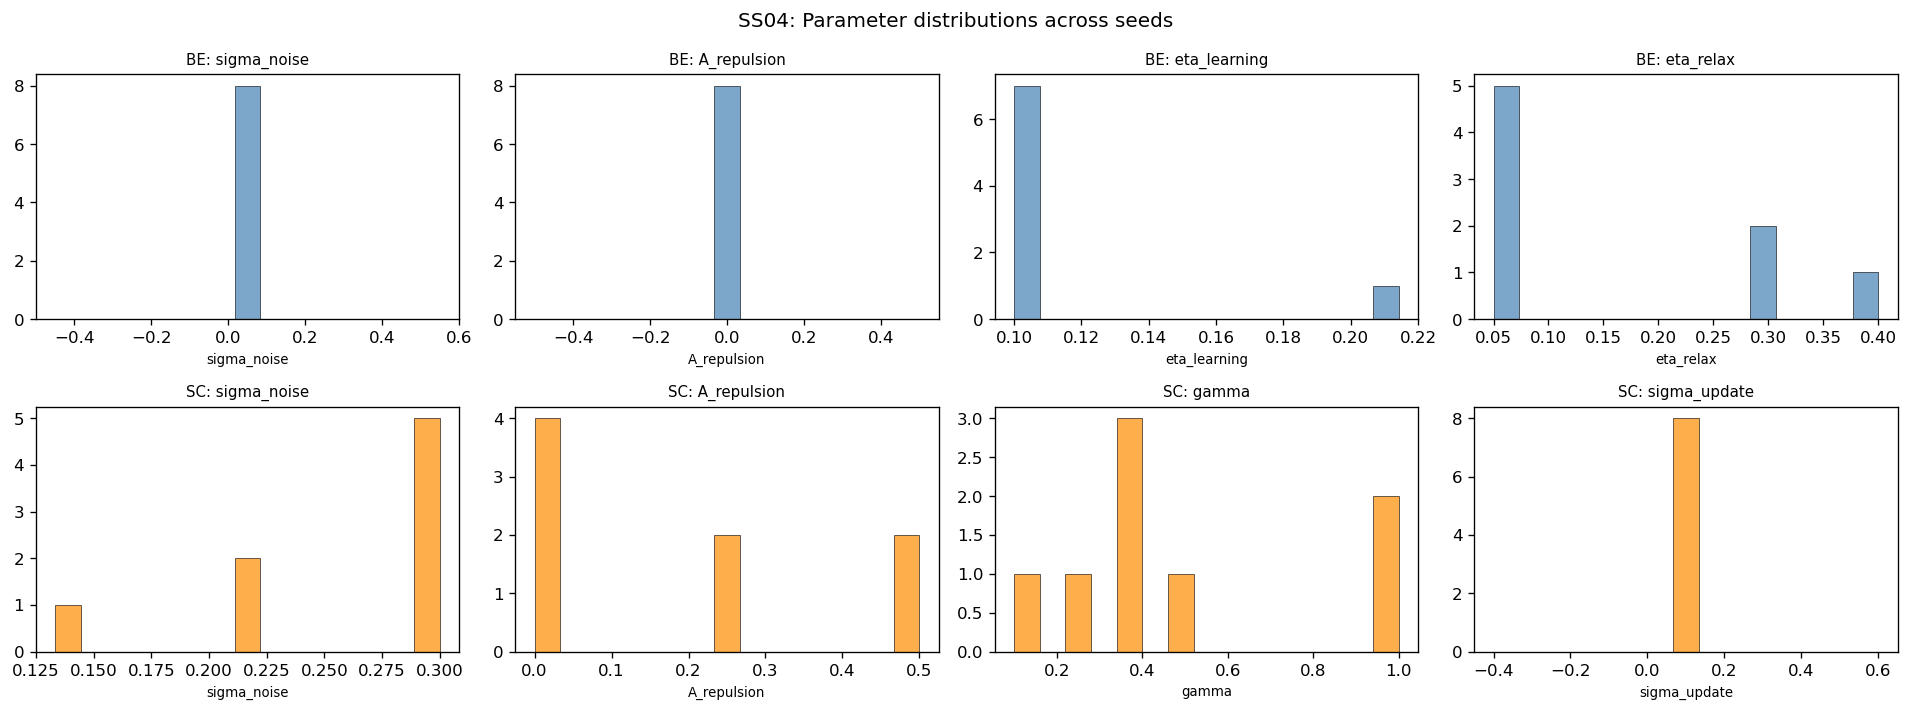

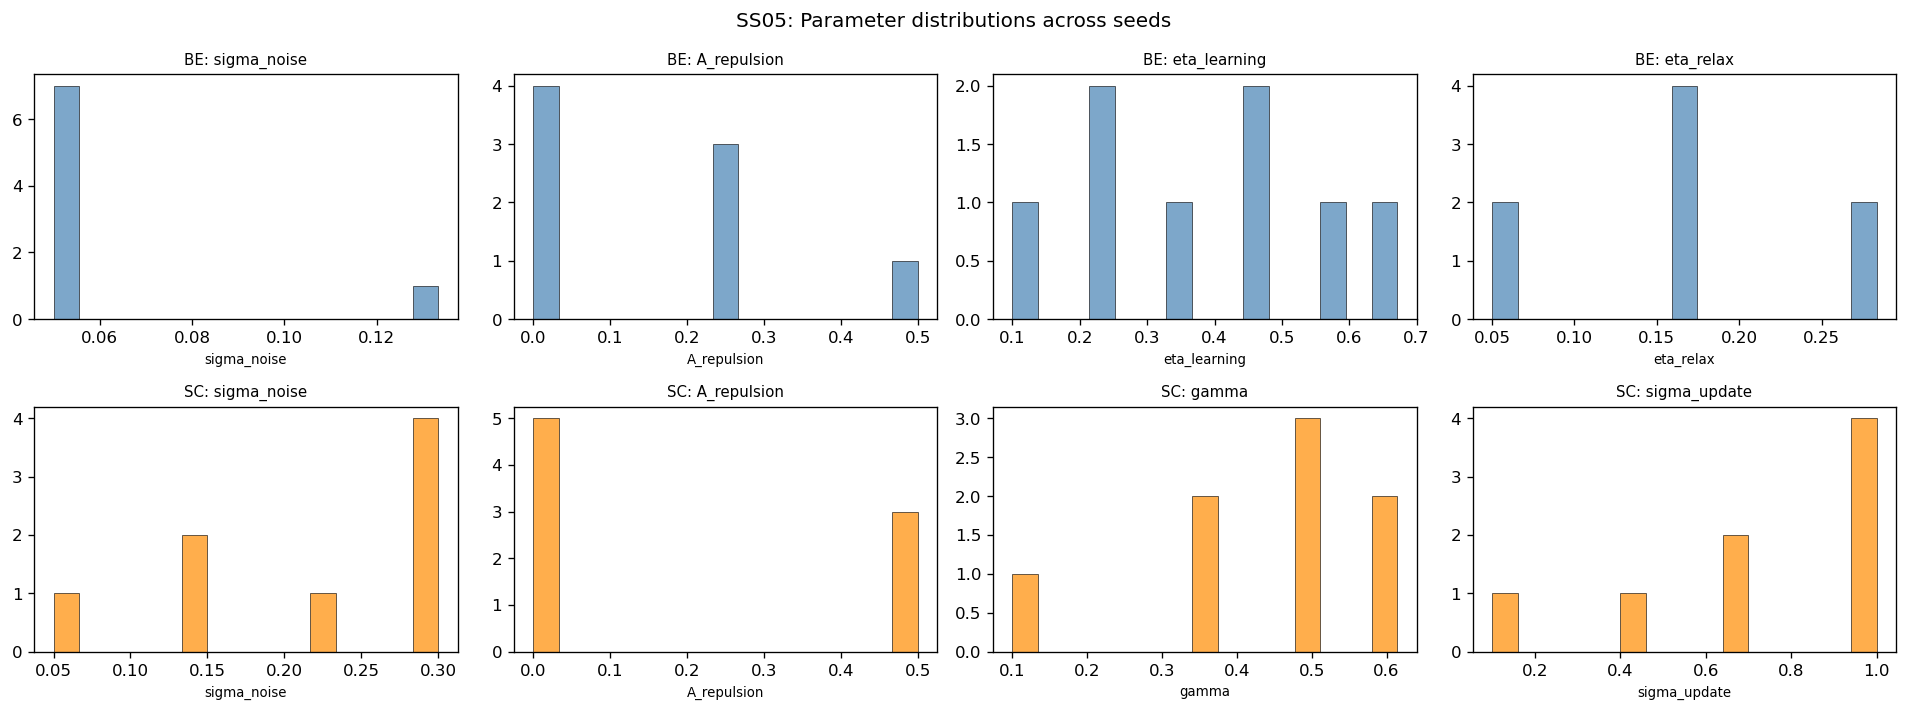

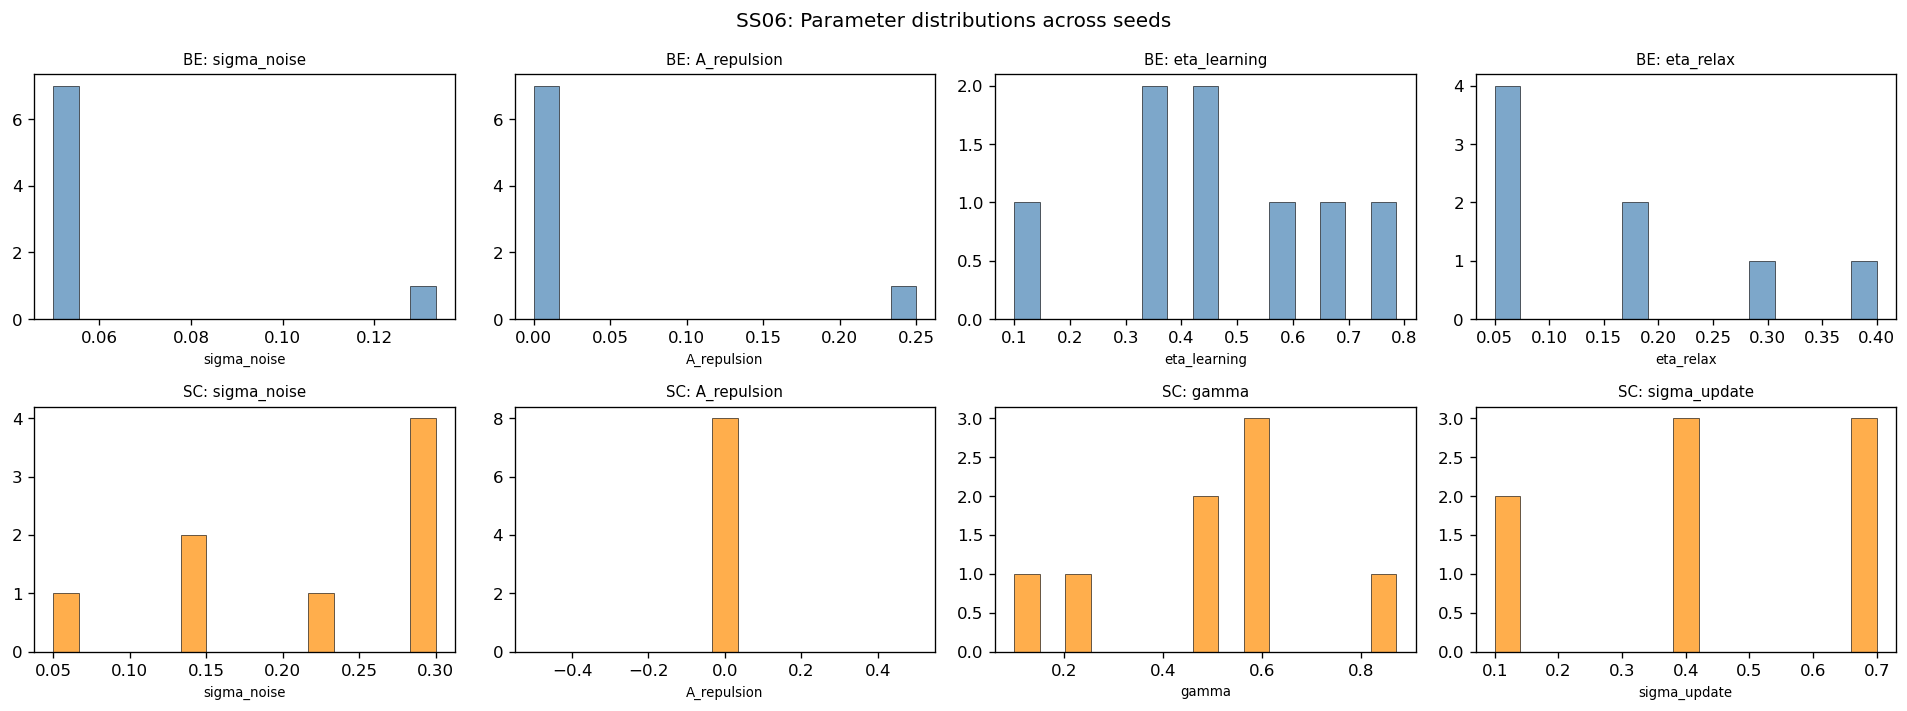

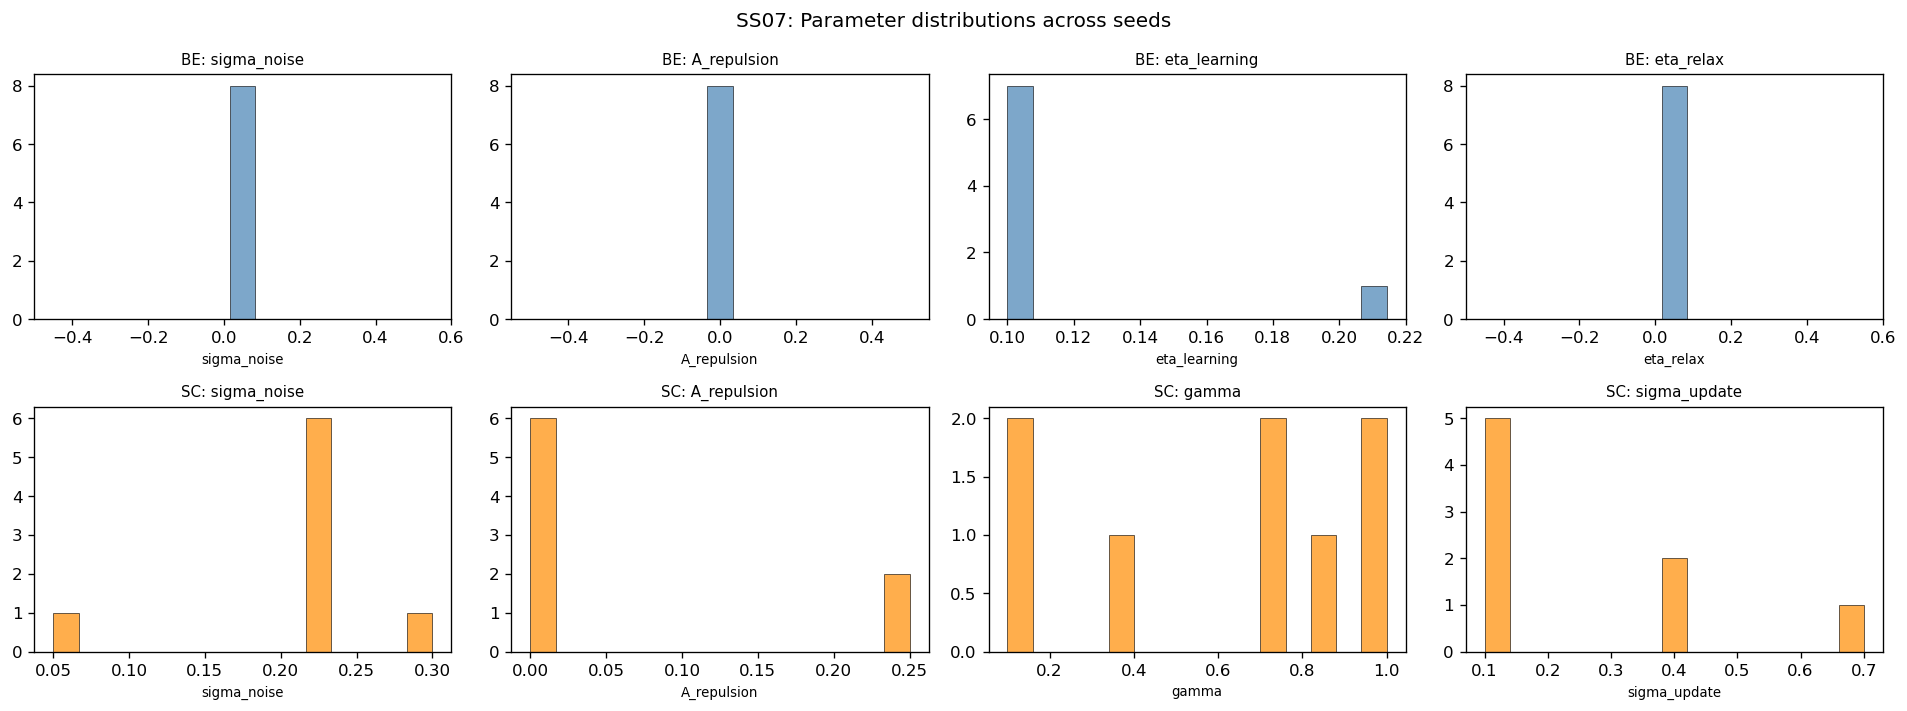

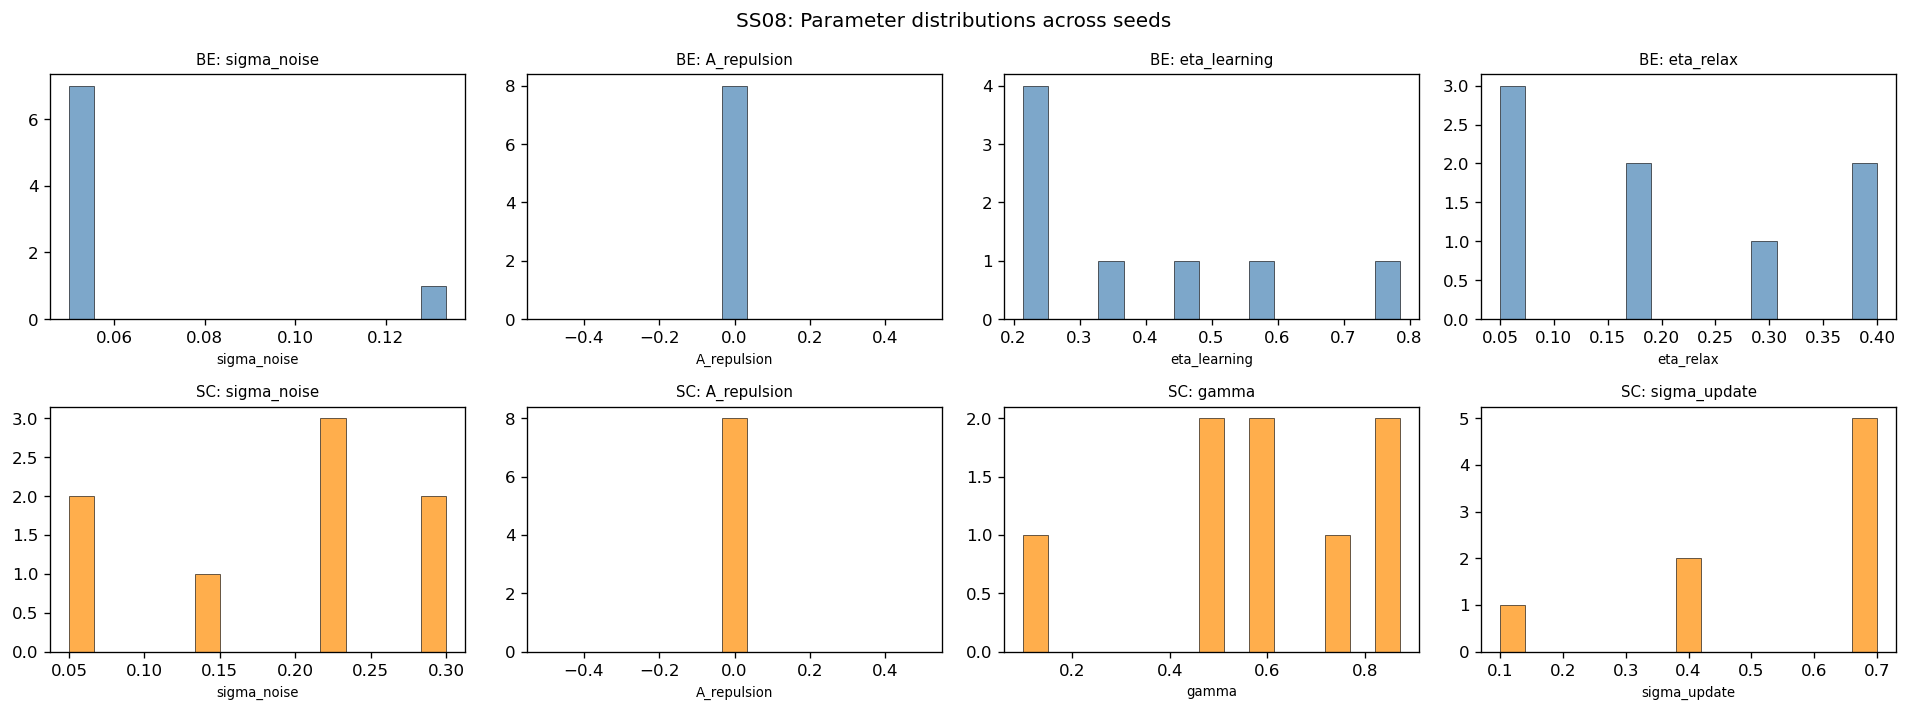

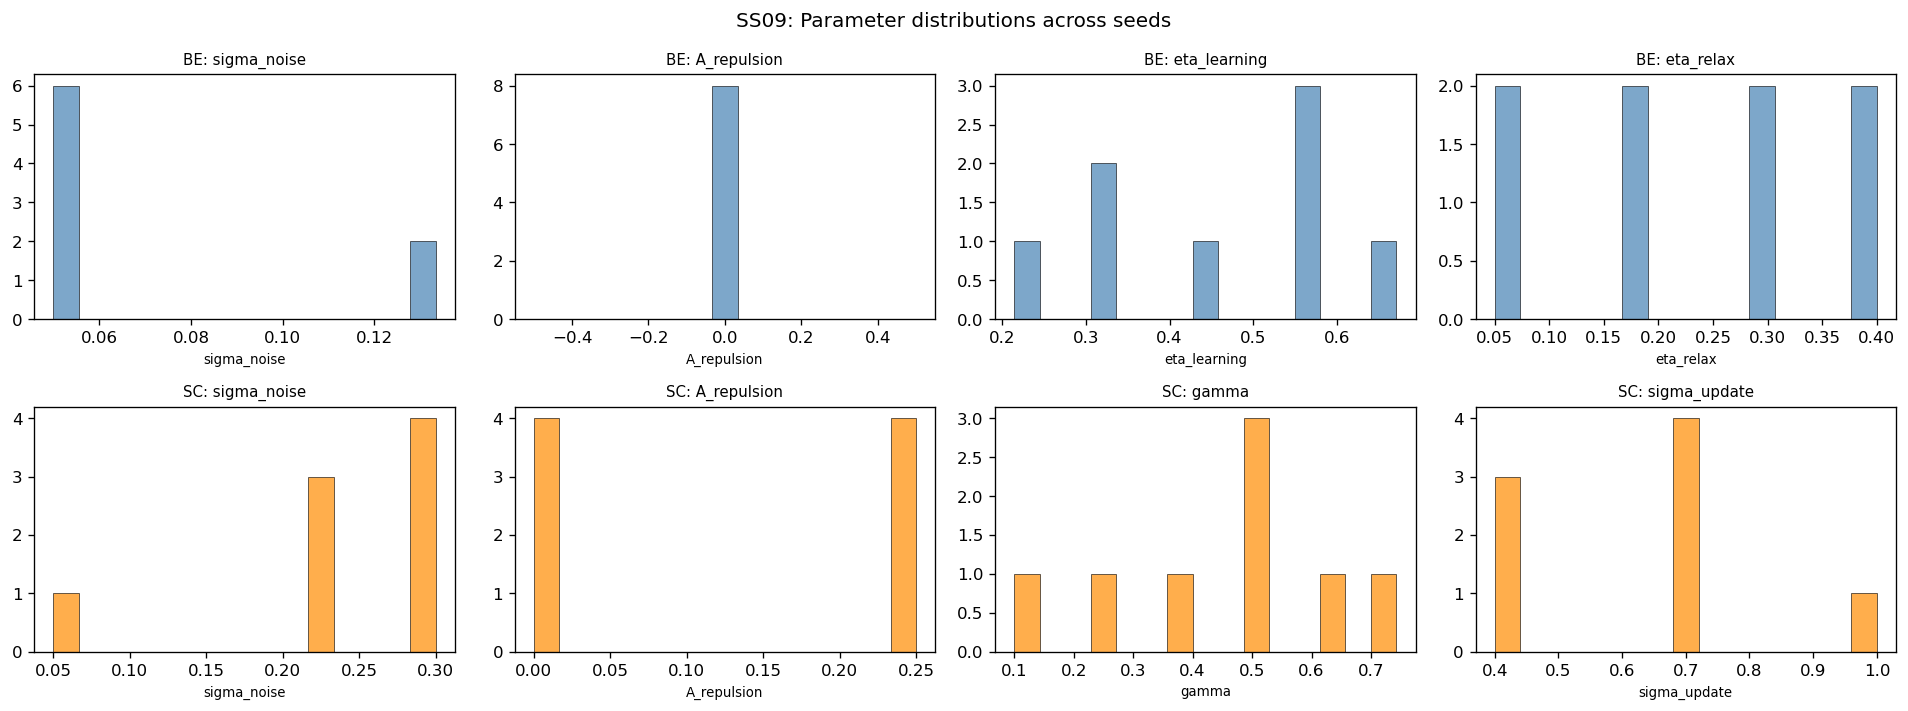

In [26]:
# ── Parameter histograms ──────────────────────────────────────────────────────
for aid in animal_dfs.keys():
    sub = param_df[param_df['Participant_ID'] == aid]

    fig, axes = plt.subplots(2, 4, figsize=(16, 6))

    # BE row
    be_sub = sub[sub['Model'] == 'BE']
    for ax, col in zip(axes[0], ['sigma_noise', 'A_repulsion', 'eta_learning', 'eta_relax']):
        vals = be_sub[col].dropna()
        if len(vals) > 0:
            ax.hist(vals, bins=15, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
        ax.set_title(f'BE: {col}', fontsize=9)
        ax.set_xlabel(col, fontsize=8)

    # SC row
    sc_sub = sub[sub['Model'] == 'SC']
    for ax, col in zip(axes[1], ['sigma_noise', 'A_repulsion', 'gamma', 'sigma_update']):
        vals = sc_sub[col].dropna()
        if len(vals) > 0:
            ax.hist(vals, bins=15, color='darkorange', alpha=0.7, edgecolor='black', linewidth=0.5)
        ax.set_title(f'SC: {col}', fontsize=9)
        ax.set_xlabel(col, fontsize=8)

    plt.suptitle(f'{aid}: Parameter distributions across seeds', fontsize=12)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'param_distributions_{aid}.png', dpi=200, bbox_inches='tight')
    plt.show()

## 11. Save Final Results

In [ ]:
# ── Save everything ───────────────────────────────────────────────────────────
long_df.to_csv(OUTPUT_DIR / 'cv_test_errors_long.csv', index=False)
comparison_df.to_csv(OUTPUT_DIR / 'cv_comparison_anova.csv', index=False)
param_df.to_csv(OUTPUT_DIR / 'cv_best_params.csv', index=False)

with open(OUTPUT_DIR / 'cv_all_results.pkl', 'wb') as f:
    pickle.dump(all_results, f)

print("Saved:")
print(f"  {OUTPUT_DIR / 'cv_test_errors_long.csv'}")
print(f"  {OUTPUT_DIR / 'cv_comparison_anova.csv'}")
print(f"  {OUTPUT_DIR / 'cv_best_params.csv'}")
print(f"  {OUTPUT_DIR / 'cv_all_results.pkl'}")

## 12. Summary

### What this notebook does

1. Loads mouse data via `behav_utils` and selects expert sessions
2. Converts to the flat DataFrame format expected by the old grid-search code
3. Runs the manuscript's exact CV protocol: 2-fold × 64 seeds, grid search over 8000 parameter combos, fit to conditional psychometric matrices
4. Compares BE vs SC per animal via ANOVA on the 64 test errors
5. Visualises: error distributions, update matrices, parameter distributions

### Caveats

- **Runtime**: With 8 cores, expect 4–10 hours per animal at 64 seeds. Use `QUICK_RUN=True` (8 seeds) for initial validation.
- **Block structure**: Mouse sessions typically have one block per session. With only ~5–10 sessions pooled, the 2-fold split may produce very uneven folds. Consider increasing `MIN_EXPERT_SESSIONS`.
- **NaN propagation**: Sparse folds can produce NaN psychometric fits, which `matrix_error` handles by ignoring NaN columns. This is the same behaviour as the manuscript code, but verify the fraction of NaN columns isn't excessive.
- **Burn-in**: The simulated 1000-trial burn-in assumes Uniform distribution. This is correct for expert-phase fitting but would need adjustment for post-shift sessions.
- **Update matrix orientation**: The old code reverses rows (`::-1`) so that the bottom row = most negative stimulus. Keep this consistent when comparing empirical vs model matrices.